# PA1 — Segmentação de instâncias

Trabalho em dupla: teste sintético, baseline binária, fronteiras + watershed, ablações, mosaico, galeria de falhas e teste de estresse. As Partes 4–6 foram integradas com a contribuição da colega. Células de treino/avaliação ainda não executadas nesta versão estão marcadas explicitamente; os resultados anteriores permanecem identificados nas Partes 0–3.

## Parte 0 — Dataset sintético

Cada imagem terá tamanho $128 \times 128$, entre 5 e 20 elipses, objetos frequentemente encostados e variações de ruído e contraste. O alvo é um mapa de instâncias: `0` representa o fundo e cada inteiro positivo identifica uma elipse diferente.

In [7]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
IMAGE_SIZE = 128
MIN_INSTANCES = 5
MAX_INSTANCES = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo selecionado: {device}")

if device.type == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name}")
    print(f"Memória total: {gpu.total_memory / 1024**3:.2f} GB")
    print(f"Compute capability: {gpu.major}.{gpu.minor}")

Dispositivo selecionado: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Memória total: 6.00 GB
Compute capability: 8.9


### Gerador de uma amostra

A função abaixo cria a imagem e seu mapa de instâncias simultaneamente. Parte das novas elipses é posicionada perto de uma elipse anterior para aumentar a frequência de objetos encostados. Uma posição só é aceita quando a elipse inteira cabe na imagem e não se sobrepõe a outra instância; portanto, cada forma permanece completa.

In [9]:
def ellipse_mask(height, width, center_y, center_x, radius_y, radius_x, angle):
    """Retorna uma máscara booleana para uma elipse rotacionada."""
    y, x = np.ogrid[:height, :width]
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    x_centered = x - center_x
    y_centered = y - center_y
    x_rot = x_centered * cos_a + y_centered * sin_a
    y_rot = -x_centered * sin_a + y_centered * cos_a
    return (x_rot / radius_x) ** 2 + (y_rot / radius_y) ** 2 <= 1


def dilate_one_pixel(mask):
    """Dilata uma máscara em um pixel usando vizinhança 8-conectada."""
    padded = np.pad(mask, 1, mode="constant")
    dilated = np.zeros_like(mask)
    for dy in range(3):
        for dx in range(3):
            dilated |= padded[dy : dy + mask.shape[0], dx : dx + mask.shape[1]]
    return dilated


def generate_synthetic_sample(rng, image_size=128, min_instances=5, max_instances=20):
    """Gera uma imagem em tons de cinza e um mapa de rótulos de instância."""
    height = width = image_size
    labels = np.zeros((height, width), dtype=np.int32)
    centers = []
    radii = []
    target_instances = int(rng.integers(min_instances, max_instances + 1))

    for instance_id in range(1, target_instances + 1):
        placed = False
        contact_requested = bool(centers and rng.random() < 0.70)

        for attempt in range(1_000):
            # Depois de 400 tentativas, usamos formas menores e priorizamos espaço livre.
            if attempt < 400:
                radius_y = int(rng.integers(5, 14))
                radius_x = int(rng.integers(5, 14))
            else:
                radius_y = int(rng.integers(4, 8))
                radius_x = int(rng.integers(4, 8))
            angle = float(rng.uniform(0, np.pi))
            try_contact = contact_requested and attempt < 400
            # Extensão do retângulo que contém a elipse após a rotação.
            extent_y = int(np.ceil(np.sqrt(
                (radius_x * np.sin(angle)) ** 2 + (radius_y * np.cos(angle)) ** 2
            )))
            extent_x = int(np.ceil(np.sqrt(
                (radius_x * np.cos(angle)) ** 2 + (radius_y * np.sin(angle)) ** 2
            )))

            if try_contact:
                neighbor_idx = int(rng.integers(len(centers)))
                neighbor_y, neighbor_x = centers[neighbor_idx]
                neighbor_ry, neighbor_rx = radii[neighbor_idx]
                direction = float(rng.uniform(0, 2 * np.pi))
                min_distance = min(neighbor_ry, neighbor_rx) + min(radius_y, radius_x)
                max_distance = max(neighbor_ry, neighbor_rx) + max(radius_y, radius_x) + 2
                distance = float(rng.uniform(min_distance, max_distance))
                center_y = int(round(neighbor_y + np.sin(direction) * distance))
                center_x = int(round(neighbor_x + np.cos(direction) * distance))
            else:
                center_y = int(rng.integers(extent_y, height - extent_y))
                center_x = int(rng.integers(extent_x, width - extent_x))

            if not (extent_y <= center_y < height - extent_y):
                continue
            if not (extent_x <= center_x < width - extent_x):
                continue

            candidate = ellipse_mask(
                height, width, center_y, center_x, radius_y, radius_x, angle
            )
            occupied = labels > 0
            overlaps = np.any(candidate & occupied)
            touches = not try_contact or np.any(dilate_one_pixel(candidate) & occupied)

            if overlaps or not touches:
                continue

            labels[candidate] = instance_id
            centers.append((center_y, center_x))
            radii.append((radius_y, radius_x))
            placed = True
            break

        if not placed:
            raise RuntimeError(
                f"Falha ao posicionar a instância {instance_id} de {target_instances}."
            )

    background = float(rng.uniform(0.05, 0.25))
    contrast = float(rng.uniform(0.45, 0.85))
    image = np.full((height, width), background, dtype=np.float32)
    for instance_id in np.unique(labels)[1:]:
        intensity = np.clip(background + contrast + rng.normal(0, 0.08), 0, 1)
        image[labels == instance_id] = intensity

    noise_std = float(rng.uniform(0.02, 0.12))
    image += rng.normal(0, noise_std, image.shape).astype(np.float32)
    image = np.clip(image, 0, 1)
    return image, labels

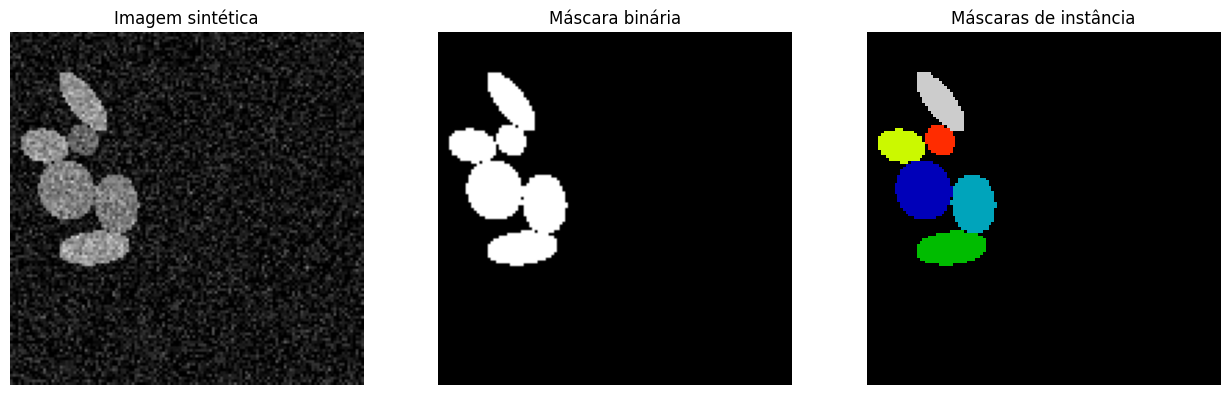

In [10]:
rng = np.random.default_rng(SEED)
sample_image, sample_labels = generate_synthetic_sample(rng, IMAGE_SIZE, MIN_INSTANCES, MAX_INSTANCES)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(sample_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Imagem sintética")
axes[1].imshow(sample_labels > 0, cmap="gray")
axes[1].set_title("Máscara binária")
axes[2].imshow(sample_labels, cmap="nipy_spectral", interpolation="nearest")
axes[2].set_title("Máscaras de instância")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
instance_ids = np.unique(sample_labels)[1:]

assert sample_image.shape == (IMAGE_SIZE, IMAGE_SIZE)
assert sample_labels.shape == (IMAGE_SIZE, IMAGE_SIZE)
assert sample_image.dtype == np.float32
assert sample_labels.dtype == np.int32
assert np.isfinite(sample_image).all()
assert 0 <= sample_image.min() <= sample_image.max() <= 1
assert np.array_equal(instance_ids, np.arange(1, len(instance_ids) + 1))
assert MIN_INSTANCES <= len(instance_ids) <= MAX_INSTANCES

print(f"Instâncias geradas: {len(instance_ids)}")
print(f"Intervalo de intensidade: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
print("Validações básicas concluídas com sucesso.")

Instâncias geradas: 6
Intervalo de intensidade: [0.000, 0.909]
Validações básicas concluídas com sucesso.


### Dataset e DataLoaders

A classe abaixo adapta o gerador à interface do PyTorch. Cada índice usa uma seed própria, o que torna as amostras reproduzíveis. Ela devolve a imagem, a máscara binária usada no treinamento da baseline, a máscara de instâncias usada na avaliação e a quantidade de objetos.

In [12]:
from torch.utils.data import DataLoader, Dataset


class SyntheticEllipsesDataset(Dataset):
    def __init__(
        self,
        num_samples,
        base_seed,
        image_size=128,
        min_instances=5,
        max_instances=20,
    ):
        self.num_samples = num_samples
        self.base_seed = base_seed
        self.image_size = image_size
        self.min_instances = min_instances
        self.max_instances = max_instances
        self._cache = {}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        if index not in self._cache:
            rng = np.random.default_rng(self.base_seed + index)
            image, instance_mask = generate_synthetic_sample(
                rng=rng,
                image_size=self.image_size,
                min_instances=self.min_instances,
                max_instances=self.max_instances,
            )
            binary_mask = (instance_mask > 0).astype(np.float32)
            self._cache[index] = {
                "image": torch.from_numpy(image).unsqueeze(0),
                "binary_mask": torch.from_numpy(binary_mask).unsqueeze(0),
                "instance_mask": torch.from_numpy(instance_mask.astype(np.int64)),
                "num_instances": int(instance_mask.max()),
            }

        return self._cache[index]

In [13]:
TRAIN_SAMPLES = 800
VAL_SAMPLES = 160
TEST_SAMPLES = 160
BATCH_SIZE = 32

train_dataset = SyntheticEllipsesDataset(TRAIN_SAMPLES, base_seed=SEED)
val_dataset = SyntheticEllipsesDataset(VAL_SAMPLES, base_seed=SEED + 10_000)
test_dataset = SyntheticEllipsesDataset(TEST_SAMPLES, base_seed=SEED + 20_000)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda",
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(f"Treino: {len(train_dataset)} imagens / {len(train_loader)} batches")
print(f"Validação: {len(val_dataset)} imagens / {len(val_loader)} batches")
print(f"Teste: {len(test_dataset)} imagens / {len(test_loader)} batches")

Treino: 800 imagens / 25 batches
Validação: 160 imagens / 5 batches
Teste: 160 imagens / 5 batches


In [14]:
first_batch = next(iter(train_loader))

assert first_batch["image"].shape == (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["binary_mask"].shape == (BATCH_SIZE, 1, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["instance_mask"].shape == (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE)
assert first_batch["image"].dtype == torch.float32
assert first_batch["binary_mask"].dtype == torch.float32
assert first_batch["instance_mask"].dtype == torch.int64
assert torch.equal(train_dataset[0]["image"], train_dataset[0]["image"])

print("Formato das imagens:       ", tuple(first_batch["image"].shape))
print("Formato das máscaras:      ", tuple(first_batch["binary_mask"].shape))
print("Formato das instâncias:    ", tuple(first_batch["instance_mask"].shape))
print("Objetos por imagem no lote:", first_batch["num_instances"].tolist())
print("Dataset e DataLoaders validados com sucesso.")

Formato das imagens:        (32, 1, 128, 128)
Formato das máscaras:       (32, 1, 128, 128)
Formato das instâncias:     (32, 128, 128)
Objetos por imagem no lote: [9, 7, 15, 5, 13, 18, 9, 20, 15, 18, 6, 18, 17, 10, 19, 20, 5, 6, 12, 5, 8, 10, 16, 6, 18, 10, 8, 19, 8, 13, 5, 7]
Dataset e DataLoaders validados com sucesso.


## U-Net pequena — baseline binária

A rede recebe uma imagem em tons de cinza e produz um logit por pixel. O encoder reduz a resolução para aprender contexto; o decoder recupera a resolução; e as *skip connections* concatenam detalhes do encoder ao decoder. A ativação sigmoide não faz parte do modelo: ela será aplicada apenas ao converter logits em probabilidades.

In [15]:
import torch.nn as nn


class DoubleConv(nn.Module):
    """Duas convoluções 3x3, cada uma seguida por BatchNorm e ReLU."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [16]:
class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c1, c2, c3, c4 = (
            base_channels,
            base_channels * 2,
            base_channels * 4,
            base_channels * 8,
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc1 = DoubleConv(in_channels, c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.bottleneck = DoubleConv(c3, c4)

        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(c3 + c3, c3)
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(c2 + c2, c2)
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(c1 + c1, c1)
        self.head = nn.Conv2d(c1, out_channels, kernel_size=1)

    def forward(self, x):
        skip1 = self.enc1(x)
        skip2 = self.enc2(self.pool(skip1))
        skip3 = self.enc3(self.pool(skip2))
        x = self.bottleneck(self.pool(skip3))

        x = self.up3(x)
        x = self.dec3(torch.cat([x, skip3], dim=1))
        x = self.up2(x)
        x = self.dec2(torch.cat([x, skip2], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, skip1], dim=1))
        return self.head(x)

In [17]:
model = SmallUNet().to(device)
test_images = first_batch["image"][:2].to(device)

model.eval()
with torch.inference_mode():
    test_logits = model(test_images)

num_parameters = sum(parameter.numel() for parameter in model.parameters())
assert test_logits.shape == test_images.shape
assert test_logits.device == test_images.device
assert torch.isfinite(test_logits).all()

print(f"Entrada:    {tuple(test_images.shape)} em {test_images.device}")
print(f"Saída:      {tuple(test_logits.shape)} em {test_logits.device}")
print(f"Parâmetros: {num_parameters:,}")
print("Forward pass concluído com sucesso.")

Entrada:    (2, 1, 128, 128) em cuda:0
Saída:      (2, 1, 128, 128) em cuda:0
Parâmetros: 482,449
Forward pass concluído com sucesso.


### Perda e métricas semânticas

A baseline será otimizada com `BCEWithLogitsLoss`. Dice e IoU serão calculados após aplicar sigmoid e limiar de 0,5. Nesta etapa, essas métricas avaliam apenas foreground versus background; elas ainda não distinguem instâncias.

In [18]:
criterion = nn.BCEWithLogitsLoss()


def binary_segmentation_metrics(logits, targets, threshold=0.5, epsilon=1e-7):
    """Calcula Dice e IoU médios por imagem a partir dos logits."""
    probabilities = torch.sigmoid(logits)
    predictions = probabilities >= threshold
    targets = targets >= 0.5

    reduce_dims = tuple(range(1, predictions.ndim))
    intersection = (predictions & targets).sum(dim=reduce_dims).float()
    predicted_area = predictions.sum(dim=reduce_dims).float()
    target_area = targets.sum(dim=reduce_dims).float()
    union = predicted_area + target_area - intersection

    dice = (2 * intersection + epsilon) / (predicted_area + target_area + epsilon)
    iou = (intersection + epsilon) / (union + epsilon)
    return {"dice": dice.mean().item(), "iou": iou.mean().item()}

In [19]:
test_targets = first_batch["binary_mask"][:2].to(device)
test_loss = criterion(test_logits, test_targets)
untrained_metrics = binary_segmentation_metrics(test_logits, test_targets)

# Logits muito positivos no objeto e negativos no fundo simulam uma predição perfeita.
perfect_logits = torch.where(test_targets > 0.5, 20.0, -20.0)
perfect_metrics = binary_segmentation_metrics(perfect_logits, test_targets)

assert torch.isfinite(test_loss)
assert 0 <= untrained_metrics["dice"] <= 1
assert 0 <= untrained_metrics["iou"] <= 1
assert abs(perfect_metrics["dice"] - 1.0) < 1e-6
assert abs(perfect_metrics["iou"] - 1.0) < 1e-6

print(f"Loss antes do treino: {test_loss.item():.4f}")
print(
    f"Modelo não treinado — Dice: {untrained_metrics['dice']:.4f} | "
    f"IoU: {untrained_metrics['iou']:.4f}"
)
print(
    f"Teste perfeito       — Dice: {perfect_metrics['dice']:.4f} | "
    f"IoU: {perfect_metrics['iou']:.4f}"
)
print("Perda e métricas validadas com sucesso.")

Loss antes do treino: 0.6340
Modelo não treinado — Dice: 0.0000 | IoU: 0.0000
Teste perfeito       — Dice: 1.0000 | IoU: 1.0000
Perda e métricas validadas com sucesso.


### Pré-validação dos splits sintéticos

Antes do treinamento, percorremos uma vez todas as seeds de treino, validação e teste. Isso confirma que o gerador consegue construir cada amostra e que todas contêm entre 5 e 20 instâncias. Como a geração é determinística por índice, as mesmas seeds serão usadas durante o treinamento.

In [20]:
for split_name, dataset in (
    ("treino", train_dataset),
    ("validação", val_dataset),
    ("teste", test_dataset),
):
    counts = [dataset[index]["num_instances"] for index in range(len(dataset))]
    assert min(counts) >= MIN_INSTANCES
    assert max(counts) <= MAX_INSTANCES
    print(
        f"{split_name.capitalize():10s}: {len(counts):4d} imagens | "
        f"instâncias entre {min(counts)} e {max(counts)}"
    )

print("Todos os splits sintéticos foram validados com sucesso.")

Treino    :  800 imagens | instâncias entre 5 e 20
Validação :  160 imagens | instâncias entre 5 e 20
Teste     :  160 imagens | instâncias entre 5 e 20
Todos os splits sintéticos foram validados com sucesso.


### Treinamento da baseline sintética

Treinaremos por 10 épocas com Adam. A cada época, a rede é avaliada sem gradientes no conjunto de validação. Guardamos em memória os pesos da época com menor loss de validação e medimos o tempo total para verificar o requisito de menos de cinco minutos.

In [21]:
import copy
import time
from tqdm.auto import tqdm


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    pbar = tqdm(loader, desc="Treino (batches)", leave=False)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / total_samples


@torch.inference_mode()
def evaluate_semantic(model, loader, criterion, device):
    model.eval()
    totals = {"loss": 0.0, "dice": 0.0, "iou": 0.0}
    total_samples = 0

    pbar = tqdm(loader, desc="Validacao", leave=False)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, targets)
        metrics = binary_segmentation_metrics(logits, targets)

        batch_size = images.shape[0]
        totals["loss"] += loss.item() * batch_size
        totals["dice"] += metrics["dice"] * batch_size
        totals["iou"] += metrics["iou"] * batch_size
        total_samples += batch_size

    return {name: value / total_samples for name, value in totals.items()}


c:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
EPOCHS = 10
LEARNING_RATE = 1e-3

# Reinicialização explícita para o experimento ser reproduzível.
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = SmallUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_val_loss = float("inf")
best_state = None
best_epoch = 0

start_time = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate_semantic(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Época {epoch:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_metrics['loss']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f}"
    )

elapsed_seconds = time.perf_counter() - start_time
model.load_state_dict(best_state)

print(f"\nMelhor época: {best_epoch} (val loss = {best_val_loss:.4f})")
print(f"Tempo total: {elapsed_seconds:.1f} s ({elapsed_seconds / 60:.2f} min)")
if elapsed_seconds <= 300:
    print("Requisito de treinamento em menos de 5 minutos atendido.")
else:
    print("Atenção: o treinamento ultrapassou 5 minutos.")

Época 01/10 | train loss: 0.4347 | val loss: 0.4200 | Dice: 0.9091 | IoU: 0.8337


Época 02/10 | train loss: 0.3396 | val loss: 0.3282 | Dice: 0.9883 | IoU: 0.9769


Época 03/10 | train loss: 0.2856 | val loss: 0.2657 | Dice: 0.9965 | IoU: 0.9931


Época 04/10 | train loss: 0.2408 | val loss: 0.2204 | Dice: 0.9965 | IoU: 0.9931


Época 05/10 | train loss: 0.2025 | val loss: 0.1880 | Dice: 0.9979 | IoU: 0.9958


Época 06/10 | train loss: 0.1701 | val loss: 0.1570 | Dice: 0.9991 | IoU: 0.9981


Época 07/10 | train loss: 0.1430 | val loss: 0.1323 | Dice: 0.9994 | IoU: 0.9988


Época 08/10 | train loss: 0.1209 | val loss: 0.1109 | Dice: 0.9995 | IoU: 0.9991


Época 09/10 | train loss: 0.1024 | val loss: 0.0951 | Dice: 0.9995 | IoU: 0.9989


Época 10/10 | train loss: 0.0870 | val loss: 0.0815 | Dice: 0.9995 | IoU: 0.9990

Melhor época: 10 (val loss = 0.0815)
Tempo total: 18.1 s (0.30 min)
Requisito de treinamento em menos de 5 minutos atendido.


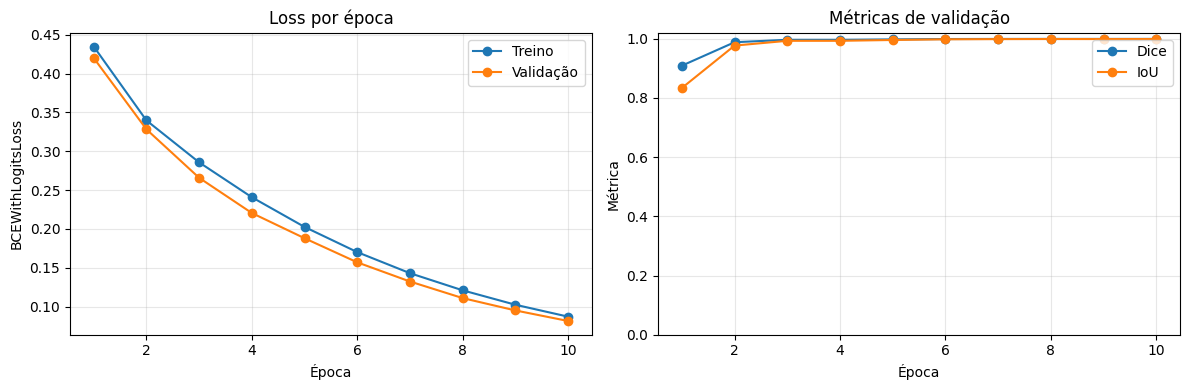

In [23]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Treino")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validação")
axes[0].set(title="Loss por época", xlabel="Época", ylabel="BCEWithLogitsLoss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["val_dice"], marker="o", label="Dice")
axes[1].plot(epochs, history["val_iou"], marker="o", label="IoU")
axes[1].set(title="Métricas de validação", xlabel="Época", ylabel="Métrica", ylim=(0, 1.02))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Avaliação semântica no conjunto de teste

Após selecionar os pesos pela menor loss de validação, avaliamos uma única vez no teste. Reportamos loss, Dice e IoU sem ajustar hiperparâmetros a partir desses resultados.

In [24]:
test_metrics = evaluate_semantic(model, test_loader, criterion, device)

assert all(np.isfinite(value) for value in test_metrics.values())
assert 0 <= test_metrics["dice"] <= 1
assert 0 <= test_metrics["iou"] <= 1

print("Resultados semânticos no teste sintético")
print("─" * 42)
print(f"Loss:  {test_metrics['loss']:.4f}")
print(f"Dice:  {test_metrics['dice']:.4f}")
print(f"IoU:   {test_metrics['iou']:.4f}")

Resultados semânticos no teste sintético
──────────────────────────────────────────
Loss:  0.0812
Dice:  0.9995
IoU:   0.9991


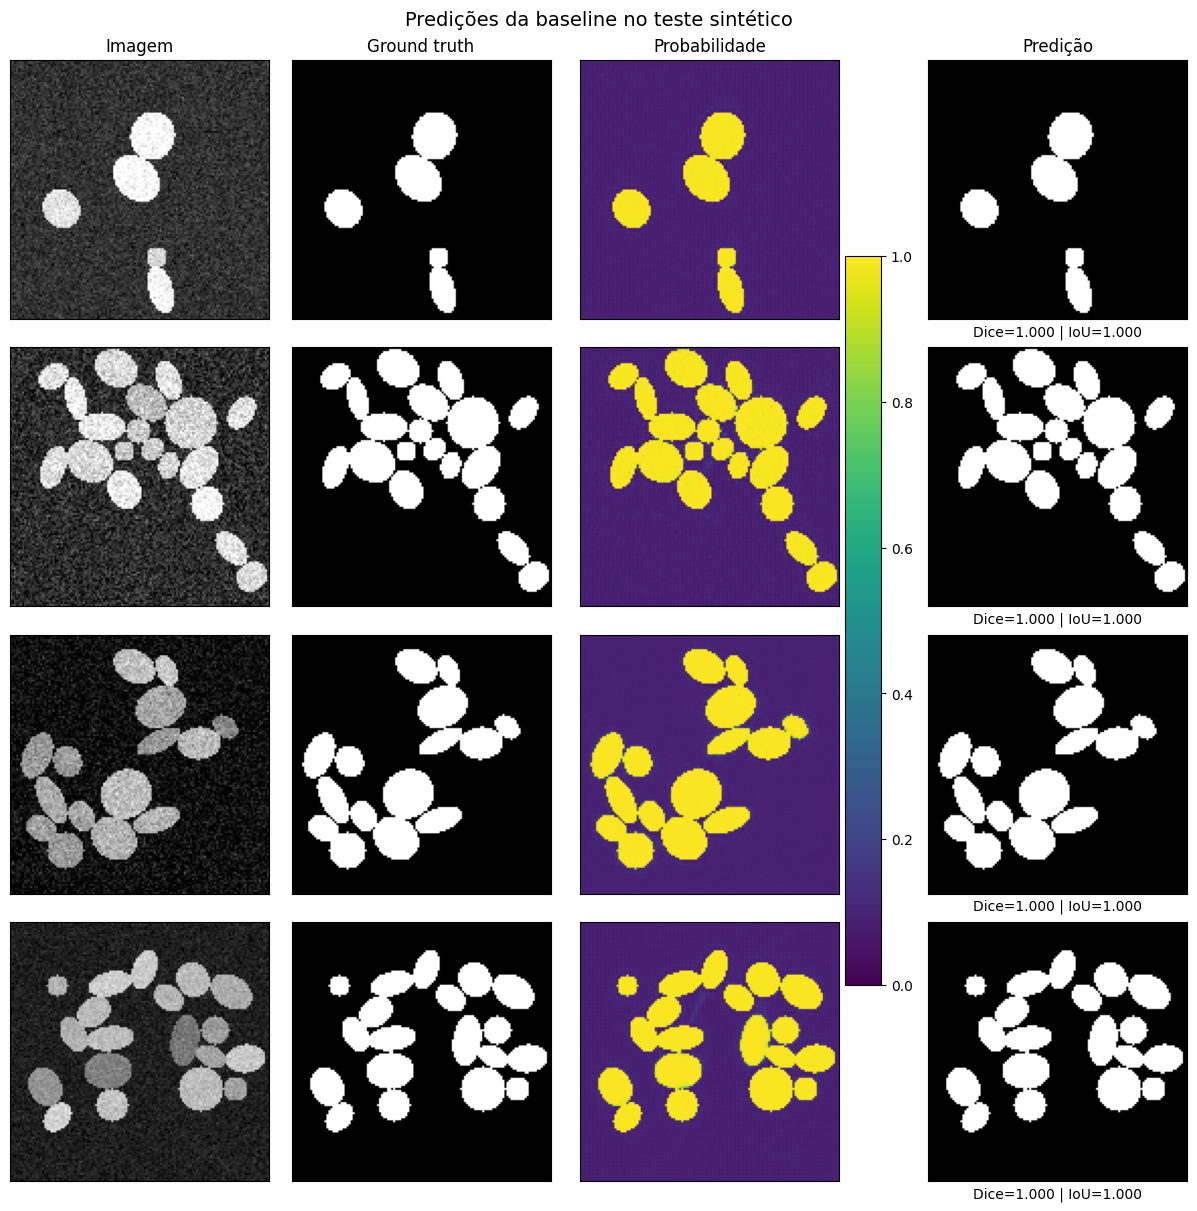

In [25]:
NUM_EXAMPLES = 4
example_batch = next(iter(test_loader))
example_images = example_batch["image"][:NUM_EXAMPLES].to(device)
example_targets = example_batch["binary_mask"][:NUM_EXAMPLES].to(device)

model.eval()
with torch.inference_mode():
    example_logits = model(example_images)
    example_probabilities = torch.sigmoid(example_logits)
    example_predictions = example_probabilities >= 0.5

images_np = example_images.cpu().numpy()
targets_np = example_targets.cpu().numpy()
probabilities_np = example_probabilities.cpu().numpy()
predictions_np = example_predictions.cpu().numpy()

fig, axes = plt.subplots(
    NUM_EXAMPLES, 4, figsize=(12, 3 * NUM_EXAMPLES), constrained_layout=True
)
column_titles = ["Imagem", "Ground truth", "Probabilidade", "Predição"]
for column, title in enumerate(column_titles):
    axes[0, column].set_title(title)

for row in range(NUM_EXAMPLES):
    sample_metrics = binary_segmentation_metrics(
        example_logits[row : row + 1], example_targets[row : row + 1]
    )
    axes[row, 0].imshow(images_np[row, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 1].imshow(targets_np[row, 0], cmap="gray", vmin=0, vmax=1)
    probability_plot = axes[row, 2].imshow(
        probabilities_np[row, 0], cmap="viridis", vmin=0, vmax=1
    )
    axes[row, 3].imshow(predictions_np[row, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 3].set_xlabel(
        f"Dice={sample_metrics['dice']:.3f} | IoU={sample_metrics['iou']:.3f}"
    )

for axis in axes.flat:
    axis.set_xticks([])
    axis.set_yticks([])
fig.colorbar(probability_plot, ax=axes[:, 2], shrink=0.65, pad=0.02)
fig.suptitle("Predições da baseline no teste sintético", fontsize=14)
plt.show()

# Parte 1 — Baseline de segmentação semântica

Usaremos as 670 imagens de `stage1_train` do BBBC038v1. O ZIP e o
`metadata.xlsx` estão no repositório; por isso a célula abaixo **verifica
primeiro os arquivos locais**. Ela só consulta o Google Drive montado ou tenta
baixar da Broad quando o dado não está disponível neste ambiente. No Colab,
o disco do Windows não aparece automaticamente em `/content`.

O split é estratificado por densidade de núcleos. O metadata é inspecionado,
mas não entra no split, pois não possui rótulo completo de modalidade para as
670 imagens. O teste ficará separado até o fim de cada escolha experimental.

In [26]:
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import urlretrieve
from zipfile import BadZipFile, ZipFile
from shutil import copy2
import time

import pandas as pd
from PIL import Image

BBBC038_BASE_URL = "https://data.broadinstitute.org/bbbc/BBBC038"
DATA_ROOT = Path("data/BBBC038")
DRIVE_CACHE_ROOT = Path("/content/drive/MyDrive/PA1/BBBC038")
ARCHIVE_PATH = DATA_ROOT / "stage1_train.zip"
METADATA_PATH = DATA_ROOT / "metadata.xlsx"
TRAIN_ROOT = DATA_ROOT / "stage1_train"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print("Ambiente:", Path.cwd().resolve())
print("Dados:", DATA_ROOT.resolve())

Ambiente: C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias
Dados: C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\data\BBBC038


In [27]:
def is_valid_zip(path):
    # Serve tanto para o .zip do dataset quanto para o .xlsx (também é ZIP).
    if not path.is_file():
        return False
    try:
        with ZipFile(path) as archive:
            return archive.testzip() is None
    except (BadZipFile, OSError):
        return False


def find_sample_dirs(root):
    if not root.is_dir():
        return []
    return sorted(
        path for path in root.iterdir()
        if path.is_dir() and (path / "images").is_dir()
        and (path / "masks").is_dir()
    )


def download_with_retries(url, destination):
    partial = destination.with_suffix(destination.suffix + ".part")
    for attempt in range(1, 4):
        try:
            urlretrieve(url, partial)
            partial.replace(destination)
            return
        except (HTTPError, URLError) as error:
            print(f"Tentativa {attempt}/3 falhou: {error}")
            if attempt == 3:
                raise RuntimeError(
                    f"Não foi possível obter {destination.name}. "
                    f"Coloque-o em {destination.resolve()} e tente novamente."
                ) from error
            time.sleep(5 * attempt)


# Um ZIP pode extrair as 670 pastas diretamente ou dentro de stage1_train/.
candidate_roots = [DATA_ROOT / "stage1_train", DATA_ROOT]
TRAIN_ROOT = max(candidate_roots, key=lambda root: len(find_sample_dirs(root)))
sample_dirs = find_sample_dirs(TRAIN_ROOT)

if len(sample_dirs) == 670:
    print("670 amostras já extraídas; não há download nem extração.")
else:
    if not is_valid_zip(ARCHIVE_PATH):
        drive_archive = DRIVE_CACHE_ROOT / "stage1_train.zip"
        if is_valid_zip(drive_archive):
            print("Copiando ZIP já existente no Drive.")
            copy2(drive_archive, ARCHIVE_PATH)
        else:
            print("ZIP ausente neste ambiente; tentando a fonte oficial.")
            download_with_retries(
                f"{BBBC038_BASE_URL}/stage1_train.zip", ARCHIVE_PATH
            )
    assert is_valid_zip(ARCHIVE_PATH), "O ZIP está incompleto ou corrompido."
    print(f"Extraindo amostras ({len(sample_dirs)}/670 já presentes)...")
    with ZipFile(ARCHIVE_PATH) as archive:
        first_parts = {Path(name).parts[0] for name in archive.namelist()
                       if Path(name).parts}
        has_wrapper = first_parts == {"stage1_train"}
        extract_root = DATA_ROOT if has_wrapper else DATA_ROOT / "stage1_train"
        extract_root.mkdir(parents=True, exist_ok=True)
        archive.extractall(extract_root)
    TRAIN_ROOT = max(candidate_roots, key=lambda root: len(find_sample_dirs(root)))
    sample_dirs = find_sample_dirs(TRAIN_ROOT)

assert len(sample_dirs) == 670, f"Encontradas {len(sample_dirs)}/670 amostras."

if not is_valid_zip(METADATA_PATH):
    drive_metadata = DRIVE_CACHE_ROOT / "metadata.xlsx"
    if is_valid_zip(drive_metadata):
        print("Copiando metadata.xlsx já existente no Drive.")
        copy2(drive_metadata, METADATA_PATH)
    else:
        try:
            print("Tentando baixar metadata.xlsx da fonte oficial.")
            download_with_retries(
                f"{BBBC038_BASE_URL}/metadata.xlsx", METADATA_PATH
            )
        except RuntimeError as error:
            print(error)
            print("Seguiremos sem metadata; o split usa densidade calculada.")

print("metadata.xlsx disponível:", is_valid_zip(METADATA_PATH))
print("Amostras:", len(sample_dirs), "em", TRAIN_ROOT.resolve())

670 amostras já extraídas; não há download nem extração.
metadata.xlsx disponível: True
Amostras: 670 em C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\data\BBBC038\stage1_train


In [28]:
sample_dirs = find_sample_dirs(TRAIN_ROOT)
assert len(sample_dirs) == 670, (
    f"Esperávamos 670 amostras, encontramos {len(sample_dirs)}."
)

first_sample_dir = sample_dirs[0]
image_paths = sorted((first_sample_dir / "images").glob("*.png"))
mask_paths = sorted((first_sample_dir / "masks").glob("*.png"))
assert len(image_paths) == 1
assert len(mask_paths) >= 1

with Image.open(image_paths[0]) as first_image:
    first_image_info = {
        "arquivo": image_paths[0].name,
        "modo": first_image.mode,
        "tamanho": first_image.size,
        "número de instâncias": len(mask_paths),
    }

if METADATA_PATH.exists() and is_valid_zip(METADATA_PATH):
    metadata = pd.read_excel(METADATA_PATH)
else:
    metadata = None

print("Primeira amostra:")
for key, value in first_image_info.items():
    print(f"  {key}: {value}")

print()
if metadata is not None:
    print(f"Metadata: {metadata.shape[0]} linhas x {metadata.shape[1]} colunas")
    display(metadata.head())
else:
    print("Metadata indisponível; a inspeção das imagens continua válida.")

Primeira amostra:
  arquivo: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png
  modo: RGBA
  tamanho: (256, 256)
  número de instâncias: 27

Metadata: 43 linhas x 13 colunas


,id,project_id,image_set,image_group,cell_type,num_images,original_res,crop_size,SNR,contrast_ratio,total_nuclei,avg_obj_size,stain_type
0,1,bbbc002,training,Default,kc167-drosophila,72,512x512,256x256,1.615410,0.340140,2947,306.247659,Hoechst 33342
1,2,bbbc018,training,Default,ht29-human-colon-cancer,144,512x512,256x256,4.812093,0.092777,4408,126.136061,"Hoechst 33342, pH3, and phalloidin"
2,3,p_06Eggert,training,Default,human,49,1040x1392,520x696,2.415012,0.294603,4566,1059.452655,NaN
3,4,p_07mito,training,Default,human-iPS-derived-oligodendrocyte,5,520x694,260x347,1.689949,0.315849,408,142.241824,Hoechst
4,5,p_15jager,training,Default,human-brain-tissue,13,512x640,512x640,2.411154,0.167754,411,1243.527609,NaN


### Imagem, máscara binária e mapa de instâncias

Cada PNG em `masks/` corresponde a um único núcleo. A união dessas máscaras produz o *ground truth* binário usado pela baseline semântica. Para preservar a identidade dos objetos, também construímos um mapa inteiro: `0` representa o fundo e `1, 2, 3, ...` representam núcleos diferentes.

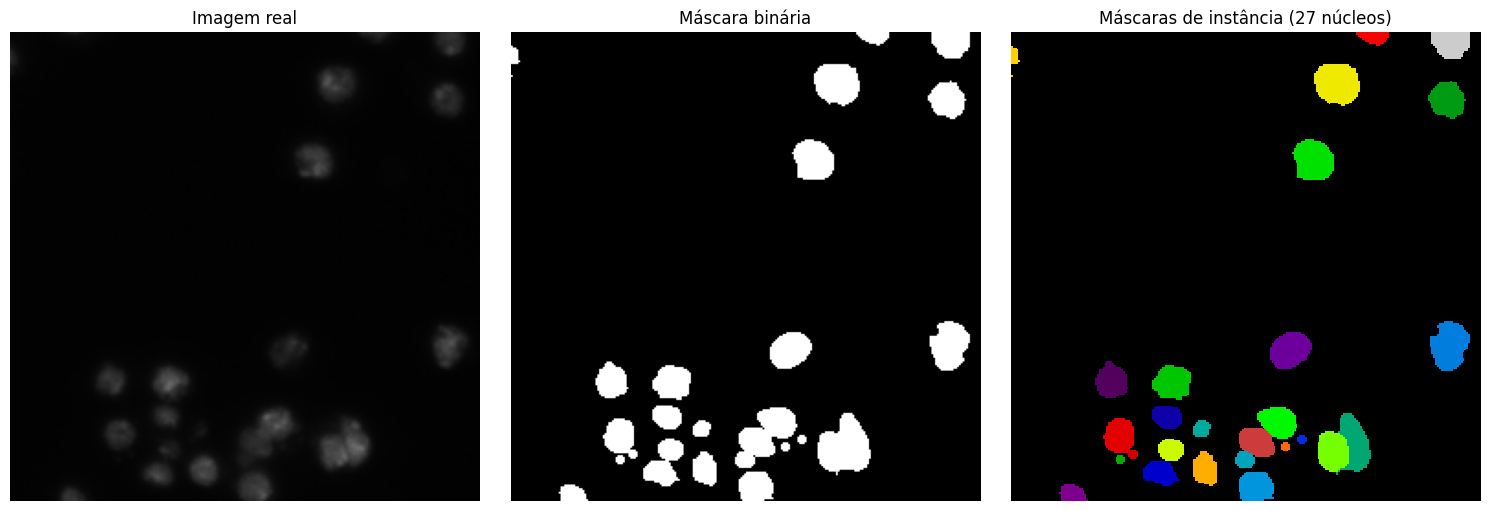

Imagem: (256, 256, 3) uint8
Máscara binária: (256, 256) bool
Mapa de instâncias: (256, 256) int32


In [29]:
def load_bbbc038_sample(sample_dir):
    image_path = next((sample_dir / "images").glob("*.png"))
    mask_paths = sorted((sample_dir / "masks").glob("*.png"))

    with Image.open(image_path) as image_file:
        image = np.asarray(image_file.convert("RGB"))

    instance_mask = np.zeros(image.shape[:2], dtype=np.int32)
    for instance_id, mask_path in enumerate(mask_paths, start=1):
        with Image.open(mask_path) as mask_file:
            object_mask = np.asarray(mask_file.convert("L")) > 0

        assert object_mask.shape == instance_mask.shape
        assert not np.any(object_mask & (instance_mask > 0)), (
            f"Máscaras sobrepostas em {sample_dir.name}."
        )
        instance_mask[object_mask] = instance_id

    binary_mask = instance_mask > 0
    return image, binary_mask, instance_mask

import numpy as np
real_image, real_binary_mask, real_instance_mask = load_bbbc038_sample(
    first_sample_dir
)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
axes[0].imshow(real_image)
axes[0].set_title("Imagem real")
axes[1].imshow(real_binary_mask, cmap="gray")
axes[1].set_title("Máscara binária")
axes[2].imshow(real_instance_mask, cmap="nipy_spectral", interpolation="nearest")
axes[2].set_title(f"Máscaras de instância ({real_instance_mask.max()} núcleos)")

for axis in axes:
    axis.axis("off")

plt.show()

print("Imagem:", real_image.shape, real_image.dtype)
print("Máscara binária:", real_binary_mask.shape, real_binary_mask.dtype)
print("Mapa de instâncias:", real_instance_mask.shape, real_instance_mask.dtype)

### Catálogo e distribuição de densidade

Criamos uma linha por imagem com suas dimensões, quantidade de instâncias e densidade de núcleos. A densidade é normalizada pela área da imagem (`núcleos por 100 mil pixels`), pois contar objetos sem considerar o tamanho da imagem produziria uma comparação injusta.

,width,height,num_instances,instances_per_100k_pixels
count,670.00,670.00,670.00,670.00
mean,378.50,333.99,43.97,37.97
std,204.84,149.47,47.96,31.83
min,256.00,256.00,1.00,0.97
25%,256.00,256.00,15.25,15.26
50%,320.00,256.00,27.00,25.59
75%,360.00,360.00,54.00,53.41
max,1388.00,1040.00,375.00,184.33


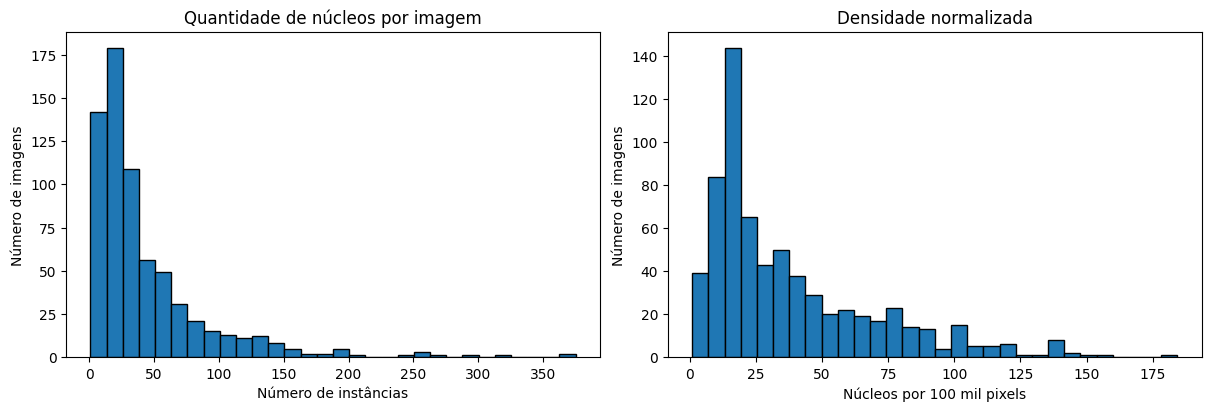

Modos de imagem:


,quantidade
mode,
RGBA,670


In [30]:
catalog_records = []

for sample_dir in sample_dirs:
    image_path = next((sample_dir / "images").glob("*.png"))
    num_instances = len(list((sample_dir / "masks").glob("*.png")))

    with Image.open(image_path) as image_file:
        width, height = image_file.size
        image_mode = image_file.mode

    area = width * height
    catalog_records.append(
        {
            "image_id": sample_dir.name,
            "width": width,
            "height": height,
            "mode": image_mode,
            "num_instances": num_instances,
            "instances_per_100k_pixels": num_instances / area * 100_000,
        }
    )

image_catalog = pd.DataFrame(catalog_records)
assert len(image_catalog) == 670
assert image_catalog["image_id"].is_unique

display(
    image_catalog[
        ["width", "height", "num_instances", "instances_per_100k_pixels"]
    ].describe().round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].hist(image_catalog["num_instances"], bins=30, edgecolor="black")
axes[0].set_title("Quantidade de núcleos por imagem")
axes[0].set_xlabel("Número de instâncias")
axes[0].set_ylabel("Número de imagens")

axes[1].hist(
    image_catalog["instances_per_100k_pixels"], bins=30, edgecolor="black"
)
axes[1].set_title("Densidade normalizada")
axes[1].set_xlabel("Núcleos por 100 mil pixels")
axes[1].set_ylabel("Número de imagens")

plt.show()

print("Modos de imagem:")
display(image_catalog["mode"].value_counts().rename("quantidade").to_frame())

### Split estratificado: treino, validação e teste

Separamos 70%/15%/15% das imagens. Como o `metadata.xlsx` descreve grupos agregados e não associa cada `image_id` a um grupo, usamos como variável observável a densidade normalizada. Cinco faixas de densidade são representadas proporcionalmente nos três splits. A semente fixa torna a divisão reprodutível.

O conjunto de validação será usado para escolher configurações e o teste ficará reservado para a avaliação final.

In [31]:
from sklearn.model_selection import train_test_split


SPLIT_SEED = 42
split_catalog = image_catalog.copy()
density_labels = ["muito baixa", "baixa", "média", "alta", "muito alta"]

# O rank(method="first") resolve empates e mantém as cinco faixas balanceadas.
split_catalog["density_bin"] = pd.qcut(
    split_catalog["instances_per_100k_pixels"].rank(method="first"),
    q=5,
    labels=density_labels,
)

train_catalog, remaining_catalog = train_test_split(
    split_catalog,
    test_size=0.30,
    random_state=SPLIT_SEED,
    stratify=split_catalog["density_bin"],
)

val_catalog, test_catalog = train_test_split(
    remaining_catalog,
    test_size=0.50,
    random_state=SPLIT_SEED,
    stratify=remaining_catalog["density_bin"],
)

train_catalog = train_catalog.sort_values("image_id").reset_index(drop=True)
val_catalog = val_catalog.sort_values("image_id").reset_index(drop=True)
test_catalog = test_catalog.sort_values("image_id").reset_index(drop=True)

train_ids = set(train_catalog["image_id"])
val_ids = set(val_catalog["image_id"])
test_ids = set(test_catalog["image_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)
assert train_ids | val_ids | test_ids == set(image_catalog["image_id"])

split_sizes = pd.Series(
    {
        "treino": len(train_catalog),
        "validação": len(val_catalog),
        "teste": len(test_catalog),
    },
    name="número de imagens",
)
display(split_sizes.to_frame())

split_summary = pd.concat(
    [
        train_catalog.assign(split="treino"),
        val_catalog.assign(split="validação"),
        test_catalog.assign(split="teste"),
    ],
    ignore_index=True,
)

display(
    pd.crosstab(split_summary["density_bin"], split_summary["split"])
    .reindex(index=density_labels, columns=["treino", "validação", "teste"])
)

display(
    split_summary.groupby("split", observed=True)[
        ["num_instances", "instances_per_100k_pixels"]
    ].mean().round(2)
)

,número de imagens
treino,469
validação,100
teste,101


split,treino,validação,teste
density_bin,,,
muito baixa,93,20,21
baixa,94,20,20
média,94,20,20
alta,94,20,20
muito alta,94,20,20


,num_instances,instances_per_100k_pixels
split,,
teste,40.13,37.51
treino,43.17,38.16
validação,51.63,37.55


### Dataset do PyTorch para os dados reais

As imagens possuem resoluções diferentes. Durante o treino extraímos recortes aleatórios de `256 × 256`, que podem ser agrupados em lotes sem deformar os núcleos. Para validação e teste mantemos a imagem completa e usamos `batch_size=1`. A imagem é convertida para um canal em escala de cinza; a máscara binária é o alvo da baseline e o mapa inteiro de instâncias será usado posteriormente nas métricas por objeto.

In [32]:
class BBBC038Dataset(Dataset):
    def __init__(self, catalog, data_root, crop_size=None, augment=False):
        self.catalog = catalog.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.crop_size = crop_size
        self.augment = augment
        self._cache = {}

    def __len__(self):
        return len(self.catalog)

    def _random_crop(self, image, binary_mask, instance_mask):
        crop_height, crop_width = self.crop_size
        height, width = image.shape

        # Padding torna a classe robusta caso apareca uma imagem menor que o crop.
        pad_height = max(0, crop_height - height)
        pad_width = max(0, crop_width - width)
        if pad_height or pad_width:
            padding = ((0, pad_height), (0, pad_width))
            image = np.pad(image, padding, mode="constant")
            binary_mask = np.pad(binary_mask, padding, mode="constant")
            instance_mask = np.pad(instance_mask, padding, mode="constant")
            height, width = image.shape

        top = np.random.randint(0, height - crop_height + 1)
        left = np.random.randint(0, width - crop_width + 1)
        rows = slice(top, top + crop_height)
        columns = slice(left, left + crop_width)
        return image[rows, columns], binary_mask[rows, columns], instance_mask[rows, columns]

    def __getitem__(self, index):
        if index not in self._cache:
            image_id = self.catalog.iloc[index]["image_id"]
            sample_dir = self.data_root / image_id
            self._cache[index] = (image_id, load_bbbc038_sample(sample_dir))

        image_id, (rgb_image, binary_mask, instance_mask) = self._cache[index]

        # A SmallUNet sintetica recebe um canal; mantemos essa interface.
        image = np.asarray(Image.fromarray(rgb_image).convert("L"), dtype=np.float32)
        image /= 255.0

        if self.crop_size is not None:
            image, binary_mask, instance_mask = self._random_crop(
                image, binary_mask, instance_mask
            )

        if self.augment:
            if np.random.random() < 0.5:
                image = np.flip(image, axis=1)
                binary_mask = np.flip(binary_mask, axis=1)
                instance_mask = np.flip(instance_mask, axis=1)
            if np.random.random() < 0.5:
                image = np.flip(image, axis=0)
                binary_mask = np.flip(binary_mask, axis=0)
                instance_mask = np.flip(instance_mask, axis=0)

        # copy() remove strides negativos criados por np.flip.
        image_tensor = torch.from_numpy(image.copy()).unsqueeze(0).float()
        binary_tensor = torch.from_numpy(binary_mask.copy()).unsqueeze(0).float()
        instance_tensor = torch.from_numpy(instance_mask.copy()).long()

        return {
            "image": image_tensor,
            "binary_mask": binary_tensor,
            "instance_mask": instance_tensor,
            "image_id": image_id,
        }


TRAIN_CROP_SIZE = (256, 256)
REAL_BATCH_SIZE = 8

real_train_dataset = BBBC038Dataset(
    train_catalog, TRAIN_ROOT, crop_size=TRAIN_CROP_SIZE, augment=True
)
real_val_dataset = BBBC038Dataset(val_catalog, TRAIN_ROOT)
real_test_dataset = BBBC038Dataset(test_catalog, TRAIN_ROOT)

loader_generator = torch.Generator().manual_seed(SPLIT_SEED)
real_train_loader = DataLoader(
    real_train_dataset,
    batch_size=REAL_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
real_val_loader = DataLoader(
    real_val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
real_test_loader = DataLoader(
    real_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

sample_batch = next(iter(real_train_loader))
print("Imagem do lote:", tuple(sample_batch["image"].shape))
print("Mascara binaria:", tuple(sample_batch["binary_mask"].shape))
print("Mapa de instancias:", tuple(sample_batch["instance_mask"].shape))
print("Intervalo da imagem:", sample_batch["image"].min().item(), "a", sample_batch["image"].max().item())


Imagem do lote: (8, 1, 256, 256)
Mascara binaria: (8, 1, 256, 256)
Mapa de instancias: (8, 256, 256)
Intervalo da imagem: 0.007843137718737125 a 1.0


### Padding para inferência em resolução completa

A U-Net reduz a resolução três vezes por um fator 2; por isso, altura e largura precisam ser divisíveis por `2³ = 8`. A função abaixo completa apenas a borda direita e inferior até o próximo múltiplo de 8, executa o modelo e remove o acréscimo da predição. O conteúdo original e as métricas permanecem com a resolução real.

In [33]:
def forward_with_padding(model, images, multiple=8):
    original_height, original_width = images.shape[-2:]
    height_remainder = original_height % multiple
    width_remainder = original_width % multiple

    if height_remainder == 0:
        pad_height = 0
    else:
        pad_height = multiple - height_remainder

    if width_remainder == 0:
        pad_width = 0
    else:
        pad_width = multiple - width_remainder

    padded_images = torch.nn.functional.pad(
        images,
        pad=(0, pad_width, 0, pad_height),
        mode="reflect",
    )
    padded_logits = model(padded_images)
    logits = padded_logits[..., :original_height, :original_width]
    return logits


height_is_irregular = val_catalog["height"] % 8 != 0
width_is_irregular = val_catalog["width"] % 8 != 0
irregular_rows = height_is_irregular | width_is_irregular
irregular_indices = val_catalog.index[irregular_rows].tolist()
assert irregular_indices, "Não foi encontrada imagem para testar o padding."

irregular_sample = real_val_dataset[irregular_indices[0]]
irregular_image = irregular_sample["image"].unsqueeze(0).to(device)
shape_check_model = SmallUNet().to(device).eval()

with torch.inference_mode():
    irregular_logits = forward_with_padding(shape_check_model, irregular_image)

assert irregular_logits.shape == irregular_image.shape
print("Entrada original:", tuple(irregular_image.shape))
print("Saída recortada:", tuple(irregular_logits.shape))
print("Teste de dimensões concluído sem erro.")

del shape_check_model, irregular_image, irregular_logits

Entrada original: (1, 1, 603, 1272)
Saída recortada: (1, 1, 603, 1272)
Teste de dimensões concluído sem erro.


### Configuração da baseline binária

A baseline usa uma nova `SmallUNet`, iniciada do zero, com uma saída por pixel. Mantemos `BCEWithLogitsLoss` para medir primeiro o desempenho da formulação binária mais simples. O Adam atualiza os pesos com taxa de aprendizado `0.001`.

In [34]:
REAL_LEARNING_RATE = 0.001
from tqdm.auto import tqdm

torch.manual_seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)

real_baseline_model = SmallUNet(
    in_channels=1,
    out_channels=1,
    base_channels=16,
).to(device)

real_baseline_criterion = nn.BCEWithLogitsLoss()
real_baseline_optimizer = torch.optim.Adam(
    real_baseline_model.parameters(),
    lr=REAL_LEARNING_RATE,
)


@torch.inference_mode()
def evaluate_real_semantic(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    number_of_images = 0

    pbar = tqdm(loader, desc="Validacao", leave=False)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["binary_mask"].to(device, non_blocking=True)

        logits = forward_with_padding(model, images)
        loss = criterion(logits, targets)
        metrics = binary_segmentation_metrics(logits, targets)

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        total_dice += metrics["dice"] * batch_size
        total_iou += metrics["iou"] * batch_size
        number_of_images += batch_size

    return {
        "loss": total_loss / number_of_images,
        "dice": total_dice / number_of_images,
        "iou": total_iou / number_of_images,
    }


number_of_parameters = sum(
    parameter.numel() for parameter in real_baseline_model.parameters()
)
print(f"Modelo criado no dispositivo: {device}")
print(f"Numero de parametros: {number_of_parameters:,}")
print(f"Learning rate: {REAL_LEARNING_RATE}")


Modelo criado no dispositivo: cuda
Numero de parametros: 482,449
Learning rate: 0.001


### Treinamento da baseline

Treinamos por 10 épocas e avaliamos o conjunto de validação ao final de cada uma. Guardamos uma cópia dos pesos sempre que a `loss` de validação diminui. Assim, a avaliação posterior usa o melhor estado observado, em vez de assumir que a última época é necessariamente a melhor.

In [35]:
from tqdm.auto import tqdm
import time
import copy

REAL_EPOCHS = 10

# Reinicia a ordem do DataLoader para tornar este experimento reproduzivel.
loader_generator.manual_seed(SPLIT_SEED)

real_training_history = []
best_validation_loss = float("inf")
best_model_state = None
training_start_time = time.perf_counter()

epoch_pbar = tqdm(range(1, REAL_EPOCHS + 1), desc="Treinamento (Epocas)")

for epoch in epoch_pbar:
    train_loss = train_one_epoch(
        real_baseline_model,
        real_train_loader,
        real_baseline_optimizer,
        real_baseline_criterion,
        device,
    )

    validation_metrics = evaluate_real_semantic(
        real_baseline_model,
        real_val_loader,
        real_baseline_criterion,
        device,
    )

    epoch_results = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": validation_metrics["loss"],
        "val_dice": validation_metrics["dice"],
        "val_iou": validation_metrics["iou"],
    }
    real_training_history.append(epoch_results)

    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = validation_metrics["loss"]
        best_model_state = copy.deepcopy(real_baseline_model.state_dict())

    epoch_pbar.set_postfix({
        "tr_loss": f"{train_loss:.4f}",
        "val_loss": f"{validation_metrics['loss']:.4f}",
        "dice": f"{validation_metrics['dice']:.4f}"
    })

    print(
        f"Epoca {epoch:02d}/{REAL_EPOCHS} | "
        f"treino loss: {train_loss:.4f} | "
        f"val loss: {validation_metrics['loss']:.4f} | "
        f"Dice: {validation_metrics['dice']:.4f} | "
        f"IoU: {validation_metrics['iou']:.4f}"
    )

training_elapsed_seconds = time.perf_counter() - training_start_time
assert best_model_state is not None
real_baseline_model.load_state_dict(best_model_state)

print()
print(f"Tempo total: {training_elapsed_seconds / 60:.2f} minutos")
print(f"Melhor loss de validacao: {best_validation_loss:.4f}")
print("Os melhores pesos foram restaurados no modelo.")


Treinamento (Epocas):  10%|█         | 1/10 [01:13<10:58, 73.21s/it, tr_loss=0.5003, val_loss=0.4183, dice=0.7990]

Epoca 01/10 | treino loss: 0.5003 | val loss: 0.4183 | Dice: 0.7990 | IoU: 0.6872


Treinamento (Epocas):  20%|██        | 2/10 [01:20<04:36, 34.61s/it, tr_loss=0.3862, val_loss=0.3743, dice=0.7265]

Epoca 02/10 | treino loss: 0.3862 | val loss: 0.3743 | Dice: 0.7265 | IoU: 0.6185


Treinamento (Epocas):  30%|███       | 3/10 [01:27<02:33, 21.96s/it, tr_loss=0.2914, val_loss=0.5017, dice=0.7783]

...

Epoca 08/10 | treino loss: 0.1234 | val loss: 0.0995 | Dice: 0.8712 | IoU: 0.7872


Treinamento (Epocas):  90%|█████████ | 9/10 [02:14<00:09,  9.66s/it, tr_loss=0.1154, val_loss=0.1683, dice=0.7878]

Epoca 09/10 | treino loss: 0.1154 | val loss: 0.1683 | Dice: 0.7878 | IoU: 0.7059


Treinamento (Epocas): 100%|██████████| 10/10 [02:25<00:00, 14.56s/it, tr_loss=0.1141, val_loss=0.1959, dice=0.8061]

Epoca 10/10 | treino loss: 0.1141 | val loss: 0.1959 | Dice: 0.8061 | IoU: 0.7351

Tempo total: 2.43 minutos
Melhor loss de validacao: 0.0995
Os melhores pesos foram restaurados no modelo.


### Curvas de treinamento da baseline

As curvas permitem verificar a convergência e comparar a evolução da função de perda com as métricas calculadas após o limiar `0.5`. Como essas medidas observam aspectos diferentes da saída, elas não precisam atingir o melhor valor na mesma época.

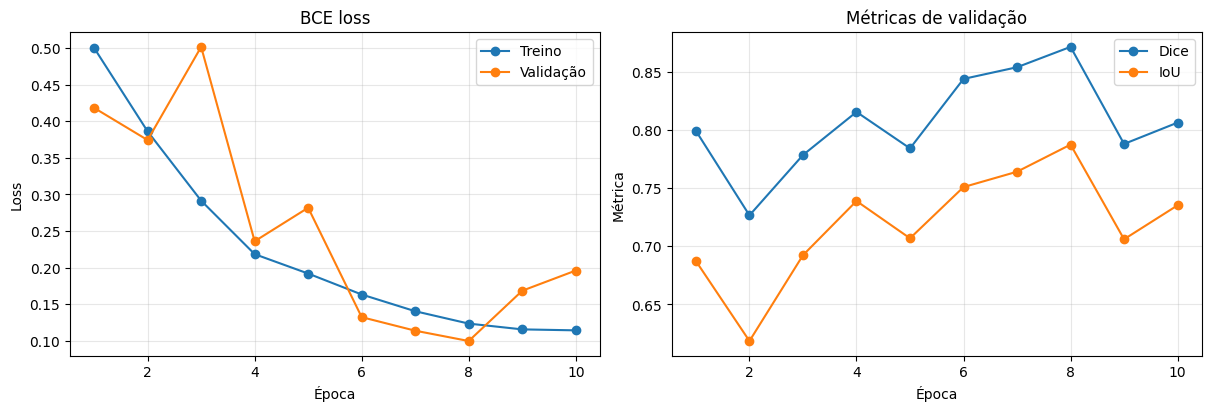

Menor val loss: época 8 (0.0995)
Maior val Dice: época 8 (0.8712)


In [36]:
real_history_frame = pd.DataFrame(real_training_history)

best_loss_row = real_history_frame.loc[real_history_frame["val_loss"].idxmin()]
best_dice_row = real_history_frame.loc[real_history_frame["val_dice"].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(
    real_history_frame["epoch"],
    real_history_frame["train_loss"],
    marker="o",
    label="Treino",
)
axes[0].plot(
    real_history_frame["epoch"],
    real_history_frame["val_loss"],
    marker="o",
    label="Validação",
)
axes[0].set_title("BCE loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    real_history_frame["epoch"],
    real_history_frame["val_dice"],
    marker="o",
    label="Dice",
)
axes[1].plot(
    real_history_frame["epoch"],
    real_history_frame["val_iou"],
    marker="o",
    label="IoU",
)
axes[1].set_title("Métricas de validação")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Métrica")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

print(
    f"Menor val loss: época {int(best_loss_row['epoch'])} "
    f"({best_loss_row['val_loss']:.4f})"
)
print(
    f"Maior val Dice: época {int(best_dice_row['epoch'])} "
    f"({best_dice_row['val_dice']:.4f})"
)

### Avaliação semântica no conjunto de teste

Depois de encerrar o treinamento e a seleção pela validação, avaliamos os pesos escolhidos nas 101 imagens de teste. O teste não participa de nenhuma atualização do modelo. Nesta etapa medimos apenas segmentação semântica; a avaliação por instância será adicionada após componentes conexos e matching.

In [37]:
real_test_metrics = evaluate_real_semantic(
    real_baseline_model,
    real_test_loader,
    real_baseline_criterion,
    device,
)

print("Baseline binária no teste")
print(f"Loss: {real_test_metrics['loss']:.4f}")
print(f"Dice: {real_test_metrics['dice']:.4f}")
print(f"IoU:  {real_test_metrics['iou']:.4f}")

Baseline binária no teste
Loss: 0.1029
Dice: 0.8778
IoU:  0.7977


### Da máscara binária para instâncias: componentes conexos

Aplicamos o limiar `0.5` às probabilidades e agrupamos pixels vizinhos. Usamos vizinhança 8: lados e diagonais contam como conexão. Cada grupo conectado recebe um ID inteiro. Esse método é a baseline de instâncias; quando dois núcleos encostam na máscara binária, eles recebem o mesmo ID e são contados como um único objeto.

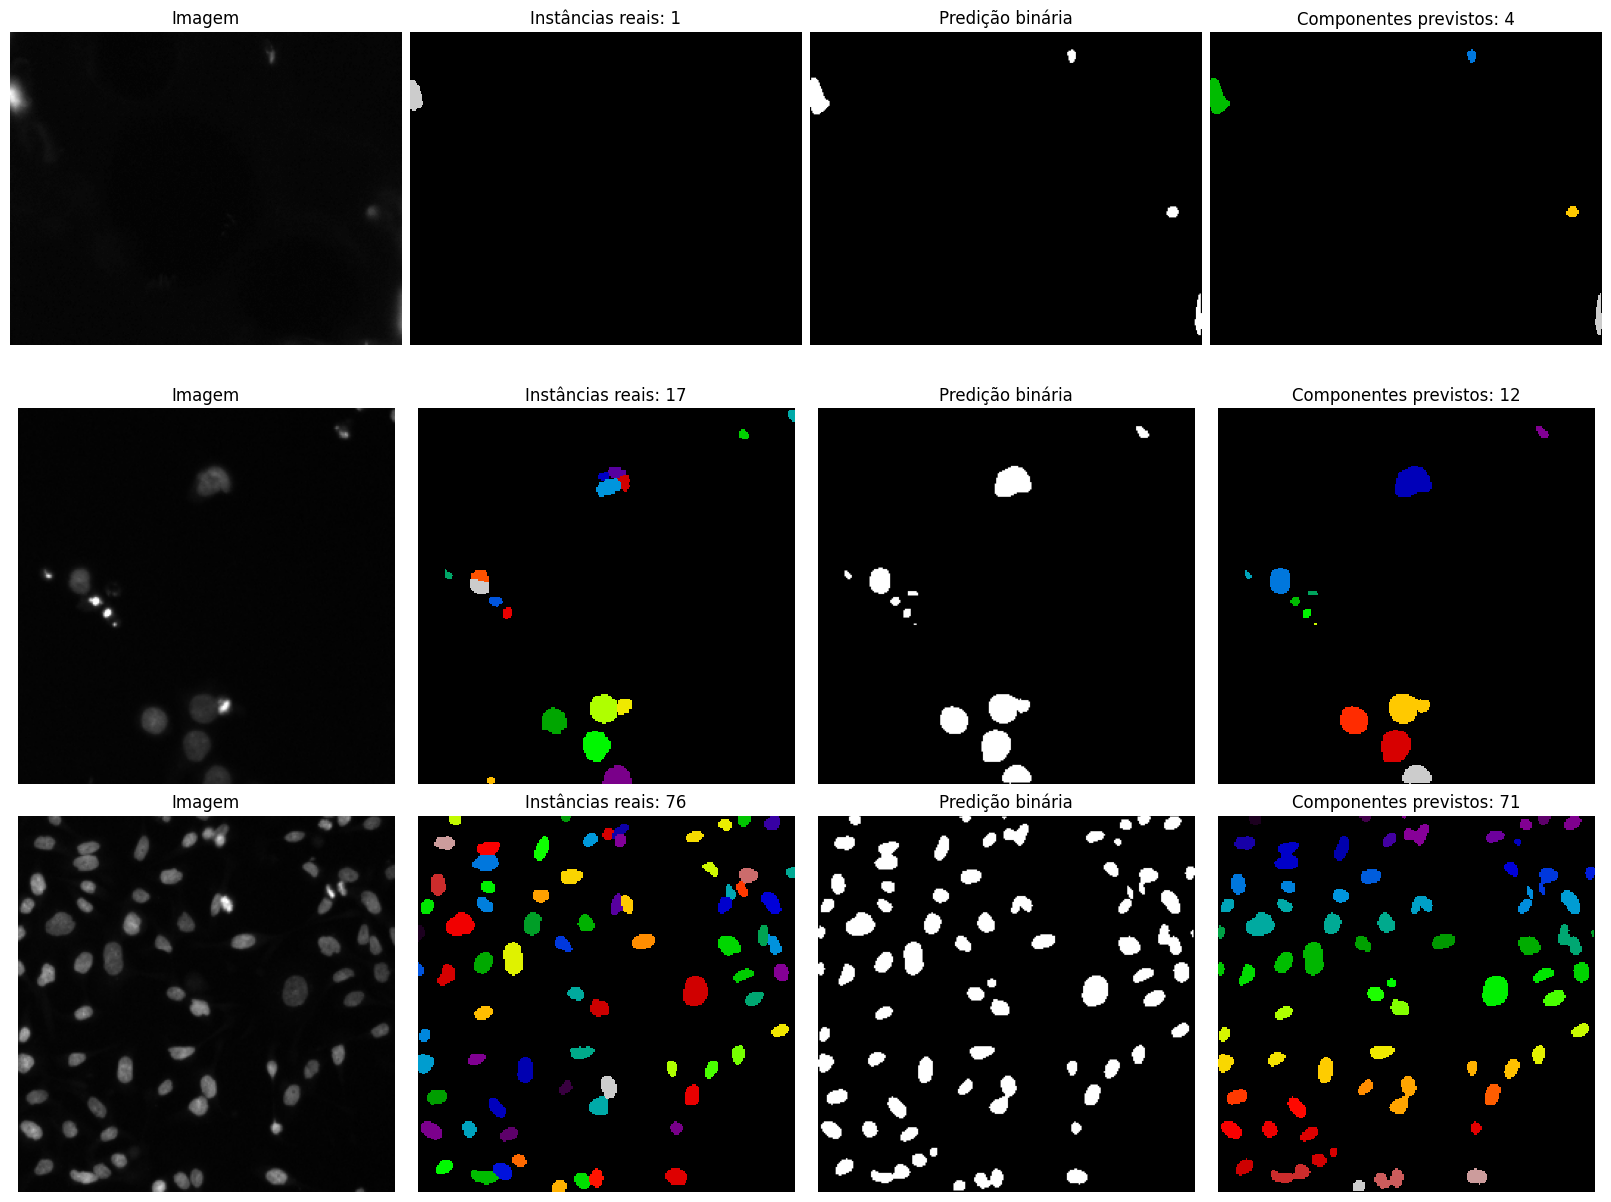

In [38]:
import scipy.ndimage as ndi


def binary_mask_to_instances(binary_mask):
    eight_neighbors = np.ones((3, 3), dtype=np.uint8)
    instance_mask, number_of_instances = ndi.label(
        binary_mask,
        structure=eight_neighbors,
    )
    return instance_mask.astype(np.int32), number_of_instances


# Escolhe exemplos nas extremidades e no meio da distribuição de densidade.
ordered_test_catalog = test_catalog.sort_values(
    "instances_per_100k_pixels"
)
selected_positions = [0, len(ordered_test_catalog) // 2, len(ordered_test_catalog) - 1]
selected_indices = ordered_test_catalog.index[selected_positions].tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 12), constrained_layout=True)
real_baseline_model.eval()

for row, dataset_index in enumerate(selected_indices):
    sample = real_test_dataset[dataset_index]
    image = sample["image"]
    true_instances = sample["instance_mask"].numpy()

    with torch.inference_mode():
        logits = forward_with_padding(
            real_baseline_model,
            image.unsqueeze(0).to(device),
        )
        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    predicted_binary = probability >= 0.5
    predicted_instances, predicted_count = binary_mask_to_instances(
        predicted_binary
    )
    true_count = int(true_instances.max())

    axes[row, 0].imshow(image[0], cmap="gray")
    axes[row, 0].set_title("Imagem")
    axes[row, 1].imshow(true_instances, cmap="nipy_spectral", interpolation="nearest")
    axes[row, 1].set_title(f"Instâncias reais: {true_count}")
    axes[row, 2].imshow(predicted_binary, cmap="gray")
    axes[row, 2].set_title("Predição binária")
    axes[row, 3].imshow(
        predicted_instances,
        cmap="nipy_spectral",
        interpolation="nearest",
    )
    axes[row, 3].set_title(f"Componentes previstos: {predicted_count}")

    for axis in axes[row]:
        axis.axis("off")

plt.show()


### Métricas por instância

Primeiro calculamos a IoU entre cada instância real e cada instância prevista. Para cada limiar de `0.50` a `0.95`, os pares são ordenados da maior para a menor IoU e cada objeto só pode ser associado uma vez. Objetos pareados são verdadeiros positivos (`TP`); previsões sem par são falsos positivos (`FP`); objetos reais sem par são falsos negativos (`FN`).

Em cada limiar calculamos `TP / (TP + FP + FN)`. O mAP da imagem é a média desses dez valores. Também calculamos `|quantidade prevista − quantidade real|`.

In [39]:
INSTANCE_IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)


def calculate_instance_iou_matrix(true_instances, predicted_instances):
    number_of_true_instances = int(true_instances.max())
    number_of_predicted_instances = int(predicted_instances.max())

    if number_of_true_instances == 0 or number_of_predicted_instances == 0:
        return np.zeros(
            (number_of_true_instances, number_of_predicted_instances),
            dtype=np.float32,
        )

    true_flat = true_instances.reshape(-1)
    predicted_flat = predicted_instances.reshape(-1)

    # Cada combinação (ID real, ID previsto) recebe um índice único.
    pair_indices = true_flat * (number_of_predicted_instances + 1)
    pair_indices = pair_indices + predicted_flat

    intersection_counts = np.bincount(
        pair_indices,
        minlength=(number_of_true_instances + 1)
        * (number_of_predicted_instances + 1),
    )
    intersection_counts = intersection_counts.reshape(
        number_of_true_instances + 1,
        number_of_predicted_instances + 1,
    )

    # A linha e a coluna zero representam o fundo e são removidas.
    intersections = intersection_counts[1:, 1:]
    true_areas = np.bincount(
        true_flat,
        minlength=number_of_true_instances + 1,
    )[1:]
    predicted_areas = np.bincount(
        predicted_flat,
        minlength=number_of_predicted_instances + 1,
    )[1:]

    unions = true_areas[:, None] + predicted_areas[None, :] - intersections
    return intersections / np.maximum(unions, 1)


def count_matches(iou_matrix, threshold):
    true_indices, predicted_indices = np.where(iou_matrix >= threshold)
    pair_scores = iou_matrix[true_indices, predicted_indices]
    order = np.argsort(pair_scores)[::-1]

    matched_true_instances = set()
    matched_predicted_instances = set()
    true_positives = 0

    for pair_index in order:
        true_index = int(true_indices[pair_index])
        predicted_index = int(predicted_indices[pair_index])

        true_already_matched = true_index in matched_true_instances
        prediction_already_matched = predicted_index in matched_predicted_instances

        if not true_already_matched and not prediction_already_matched:
            matched_true_instances.add(true_index)
            matched_predicted_instances.add(predicted_index)
            true_positives += 1

    return true_positives


def calculate_instance_metrics(true_instances, predicted_instances):
    number_of_true_instances = int(true_instances.max())
    number_of_predicted_instances = int(predicted_instances.max())
    iou_matrix = calculate_instance_iou_matrix(
        true_instances,
        predicted_instances,
    )

    scores_by_threshold = []

    for threshold in INSTANCE_IOU_THRESHOLDS:
        true_positives = count_matches(iou_matrix, threshold)
        false_positives = number_of_predicted_instances - true_positives
        false_negatives = number_of_true_instances - true_positives
        denominator = true_positives + false_positives + false_negatives

        if denominator == 0:
            score = 1.0
        else:
            score = true_positives / denominator

        scores_by_threshold.append(score)

    return {
        "map": float(np.mean(scores_by_threshold)),
        "count_error": abs(
            number_of_predicted_instances - number_of_true_instances
        ),
        "true_count": number_of_true_instances,
        "predicted_count": number_of_predicted_instances,
        "scores_by_threshold": scores_by_threshold,
    }


# Teste 1: uma previsão idêntica ao ground truth deve obter mAP 1.
small_ground_truth = np.array(
    [
        [0, 1, 1, 0],
        [0, 1, 1, 0],
        [0, 0, 2, 2],
        [0, 0, 2, 2],
    ],
    dtype=np.int32,
)
perfect_prediction = small_ground_truth.copy()
perfect_metrics = calculate_instance_metrics(
    small_ground_truth,
    perfect_prediction,
)
assert np.isclose(perfect_metrics["map"], 1.0)
assert perfect_metrics["count_error"] == 0

# Teste 2: unir os dois objetos em um só deve piorar o resultado.
merged_prediction = (small_ground_truth > 0).astype(np.int32)
merged_metrics = calculate_instance_metrics(
    small_ground_truth,
    merged_prediction,
)
assert merged_metrics["map"] < perfect_metrics["map"]
assert merged_metrics["count_error"] == 1

print("Previsão perfeita:", perfect_metrics)
print("Objetos unidos:", merged_metrics)
print("Testes das métricas concluídos sem erro.")

Previsão perfeita: {'map': 1.0, 'count_error': 0, 'true_count': 2, 'predicted_count': 2, 'scores_by_threshold': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}
Objetos unidos: {'map': 0.05, 'count_error': 1, 'true_count': 2, 'predicted_count': 1, 'scores_by_threshold': [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}
Testes das métricas concluídos sem erro.


### Avaliação de instâncias da baseline no teste

Para cada imagem de teste, convertemos os logits em probabilidades, aplicamos o limiar `0.5` e rotulamos os componentes conexos. Em seguida calculamos o mAP, o erro absoluto de contagem e o resultado em cada limiar de IoU. Mantemos uma linha por imagem para permitir análises posteriores por densidade.

In [40]:
baseline_instance_records = []
real_baseline_model.eval()

for dataset_index in range(len(real_test_dataset)):
    sample = real_test_dataset[dataset_index]
    image = sample["image"]
    true_instances = sample["instance_mask"].numpy()

    with torch.inference_mode():
        logits = forward_with_padding(
            real_baseline_model,
            image.unsqueeze(0).to(device),
        )
        probability = torch.sigmoid(logits)[0, 0].cpu().numpy()

    predicted_binary = probability >= 0.5
    predicted_instances, _ = binary_mask_to_instances(predicted_binary)
    metrics = calculate_instance_metrics(
        true_instances,
        predicted_instances,
    )

    catalog_row = test_catalog.iloc[dataset_index]
    record = {
        "image_id": sample["image_id"],
        "density": catalog_row["instances_per_100k_pixels"],
        "density_bin": catalog_row["density_bin"],
        "map": metrics["map"],
        "count_error": metrics["count_error"],
        "count_bias": metrics["predicted_count"] - metrics["true_count"],
        "true_count": metrics["true_count"],
        "predicted_count": metrics["predicted_count"],
    }

    for threshold, score in zip(
        INSTANCE_IOU_THRESHOLDS,
        metrics["scores_by_threshold"],
    ):
        column_name = f"score_iou_{threshold:.2f}"
        record[column_name] = score

    baseline_instance_records.append(record)

    number_processed = dataset_index + 1
    if number_processed % 20 == 0 or number_processed == len(real_test_dataset):
        print(f"Processadas {number_processed}/{len(real_test_dataset)} imagens")

baseline_instance_results = pd.DataFrame(baseline_instance_records)
assert len(baseline_instance_results) == len(real_test_dataset)

baseline_map = baseline_instance_results["map"].mean()
baseline_count_mae = baseline_instance_results["count_error"].mean()
baseline_count_bias = baseline_instance_results["count_bias"].mean()

print()
print("Baseline de instâncias no teste")
print(f"mAP (IoU 0.50:0.95): {baseline_map:.4f}")
print(f"Erro absoluto médio de contagem: {baseline_count_mae:.2f}")
print(f"Viés médio de contagem: {baseline_count_bias:+.2f}")

threshold_columns = [
    f"score_iou_{threshold:.2f}" for threshold in INSTANCE_IOU_THRESHOLDS
]
mean_score_by_threshold = baseline_instance_results[threshold_columns].mean()
display(mean_score_by_threshold.rename("score médio").to_frame())

Processadas 20/101 imagens
Processadas 40/101 imagens
Processadas 60/101 imagens
Processadas 80/101 imagens
Processadas 100/101 imagens
Processadas 101/101 imagens

Baseline de instâncias no teste
mAP (IoU 0.50:0.95): 0.4318
Erro absoluto médio de contagem: 10.19
Viés médio de contagem: -8.88


,score médio
score_iou_0.50,0.634308
score_iou_0.55,0.602863
score_iou_0.60,0.564869
score_iou_0.65,0.529491
score_iou_0.70,0.500390
score_iou_0.75,0.463385
score_iou_0.80,0.402725
score_iou_0.85,0.326114
score_iou_0.90,0.223924
score_iou_0.95,0.069462


### Falha da baseline em função da densidade

Agrupamos as imagens nas mesmas cinco faixas de densidade usadas no split. Em cada faixa mostramos o mAP médio e o erro absoluto médio de contagem. Essa análise verifica se a baseline se degrada quando há mais núcleos próximos e, portanto, mais oportunidades de fusão.

,number_of_images,mean_map,mean_count_error,mean_count_bias
density_bin,,,,
muito baixa,21,0.568,3.19,2.714
baixa,20,0.556,3.05,-2.850
média,20,0.373,5.20,-5.100
alta,20,0.391,8.85,-8.850
muito alta,20,0.264,31.00,-30.900


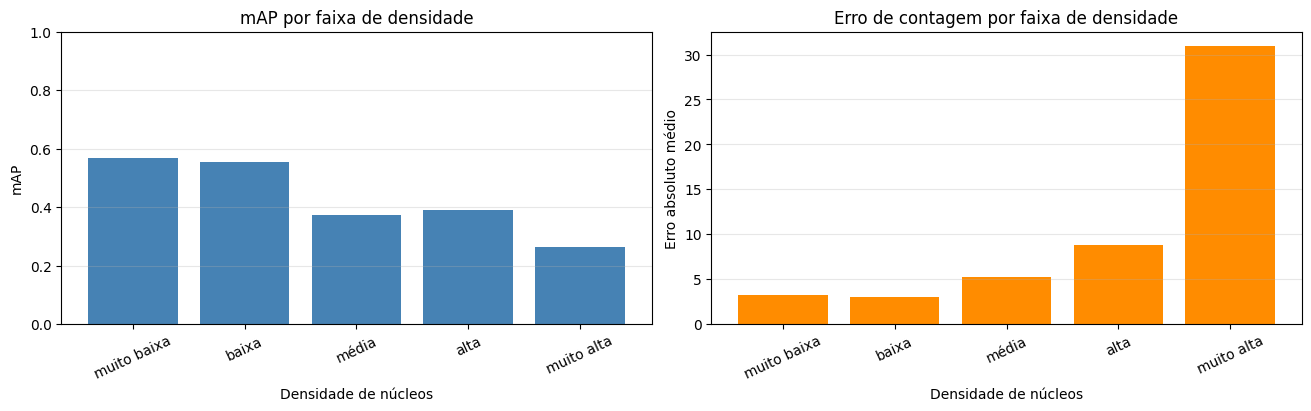

In [41]:
density_failure_summary = (
    baseline_instance_results.groupby("density_bin", observed=True)
    .agg(
        number_of_images=("image_id", "count"),
        mean_map=("map", "mean"),
        mean_count_error=("count_error", "mean"),
        mean_count_bias=("count_bias", "mean"),
    )
    .reindex(density_labels)
)

display(density_failure_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].bar(
    density_failure_summary.index,
    density_failure_summary["mean_map"],
    color="steelblue",
)
axes[0].set_title("mAP por faixa de densidade")
axes[0].set_xlabel("Densidade de núcleos")
axes[0].set_ylabel("mAP")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    density_failure_summary.index,
    density_failure_summary["mean_count_error"],
    color="darkorange",
)
axes[1].set_title("Erro de contagem por faixa de densidade")
axes[1].set_xlabel("Densidade de núcleos")
axes[1].set_ylabel("Erro absoluto médio")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.show()

## Parte 2 - Cabeça de instâncias com fronteiras e watershed

A baseline reconhece bem os pixels pertencentes a núcleos, mas componentes conexos não separam objetos que se tocam. Mantemos o encoder-decoder da Parte 1 e alteramos somente a saída para três classes: `0 = fundo`, `1 = interior` e `2 = fronteira`. Os interiores previstos serão os marcadores do watershed.

### Construção do alvo de fronteiras

Comparamos o ID de cada pixel de objeto com seus oito vizinhos. Se algum vizinho tiver ID diferente, o pixel pertence à fronteira interna. Isso cria uma borda de um pixel; quando duas instâncias se tocam, há um pixel de fronteira de cada lado da divisão.

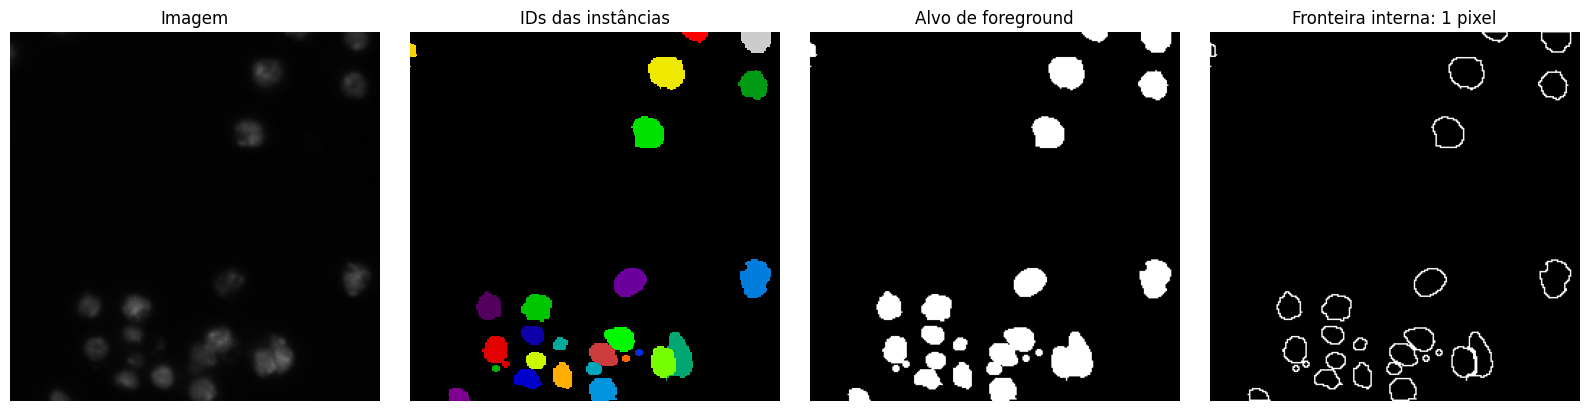

Pixels de foreground: 5715
Pixels de fronteira: 1583


In [42]:
def create_boundary_target(instance_mask):
    height, width = instance_mask.shape
    padded_mask = np.pad(instance_mask, pad_width=1, mode="constant")
    boundary_mask = np.zeros(instance_mask.shape, dtype=bool)
    foreground_mask = instance_mask > 0
    

    # Compara cada pixel com os oito vizinhos ao seu redor.
    for row_offset in [-1, 0, 1]:
        for column_offset in [-1, 0, 1]:
            if row_offset == 0 and column_offset == 0:
                continue

            row_start = 1 + row_offset
            column_start = 1 + column_offset
            neighbor_mask = padded_mask[
                row_start:row_start + height,
                column_start:column_start + width,
            ]

            different_neighbor = neighbor_mask != instance_mask
            boundary_mask |= foreground_mask & different_neighbor

    return boundary_mask


example_boundary = create_boundary_target(real_instance_mask)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
axes[0].imshow(real_image)
axes[0].set_title("Imagem")
axes[1].imshow(real_instance_mask, cmap="nipy_spectral", interpolation="nearest")
axes[1].set_title("IDs das instâncias")
axes[2].imshow(real_binary_mask, cmap="gray")
axes[2].set_title("Alvo de foreground")
axes[3].imshow(example_boundary, cmap="gray")
axes[3].set_title("Fronteira interna: 1 pixel")

for axis in axes:
    axis.axis("off")

plt.show()

assert example_boundary.shape == real_binary_mask.shape
assert np.all(example_boundary <= real_binary_mask)
print("Pixels de foreground:", int(real_binary_mask.sum()))
print("Pixels de fronteira:", int(example_boundary.sum()))

### Dataset com três classes

Esta classe herda o carregamento, o crop e os aumentos do `BBBC038Dataset`. Depois dessas transformações, ela usa o mapa de IDs para construir um alvo inteiro: fundo recebe `0`, interior recebe `1` e fronteira recebe `2`. Fazer isso no final mantém todos os mapas espacialmente alinhados.

In [43]:
class BBBC038BoundaryDataset(BBBC038Dataset):
    def __getitem__(self, index):
        sample = super().__getitem__(index)

        instance_mask = sample["instance_mask"].numpy()
        foreground_mask = sample["binary_mask"][0].numpy().astype(bool)
        boundary_mask = create_boundary_target(instance_mask)
        interior_mask = foreground_mask & ~boundary_mask

        class_mask = np.zeros(instance_mask.shape, dtype=np.int64)
        class_mask[interior_mask] = 1
        class_mask[boundary_mask] = 2

        sample["boundary_mask"] = torch.from_numpy(boundary_mask).unsqueeze(0).float()
        sample["class_mask"] = torch.from_numpy(class_mask).long()
        return sample


boundary_train_dataset = BBBC038BoundaryDataset(
    train_catalog,
    TRAIN_ROOT,
    crop_size=TRAIN_CROP_SIZE,
    augment=True,
)
boundary_val_dataset = BBBC038BoundaryDataset(val_catalog, TRAIN_ROOT)
boundary_test_dataset = BBBC038BoundaryDataset(test_catalog, TRAIN_ROOT)

boundary_loader_generator = torch.Generator().manual_seed(SPLIT_SEED)
boundary_train_loader = DataLoader(
    boundary_train_dataset,
    batch_size=REAL_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=boundary_loader_generator,
)
boundary_val_loader = DataLoader(
    boundary_val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
boundary_test_loader = DataLoader(
    boundary_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

boundary_batch = next(iter(boundary_train_loader))
print("Imagens:", tuple(boundary_batch["image"].shape))
print("Classes:", tuple(boundary_batch["class_mask"].shape))
print("Valores presentes:", torch.unique(boundary_batch["class_mask"]).tolist())
print("0 = fundo, 1 = interior, 2 = fronteira")

Imagens: (8, 1, 256, 256)
Classes: (8, 256, 256)
Valores presentes: [0, 1, 2]
0 = fundo, 1 = interior, 2 = fronteira


### Modelo e CE balanceada

Contamos os pixels das três classes nos crops de treino. Para cada classe, o peso é inversamente proporcional à sua frequência: `total de pixels / (3 x pixels da classe)`. A fronteira, que é rara, recebe peso maior. A Small U-Net passa a produzir três logits por pixel, e a `CrossEntropyLoss` compara esses logits com o alvo inteiro `0/1/2`.

In [44]:
class_pixel_counts = torch.zeros(3, dtype=torch.long)

for batch in boundary_train_loader:
    class_masks = batch["class_mask"]
    batch_counts = torch.bincount(class_masks.reshape(-1), minlength=3)
    class_pixel_counts += batch_counts

total_class_pixels = class_pixel_counts.sum()
class_frequencies = class_pixel_counts.float() / total_class_pixels
class_weights = total_class_pixels / (3 * class_pixel_counts.float())

class_names = ["fundo", "interior", "fronteira"]
for class_index, class_name in enumerate(class_names):
    print(
        f"{class_name:10s} | "
        f"frequência: {class_frequencies[class_index].item():.4f} | "
        f"peso: {class_weights[class_index].item():.2f}"
    )

# A contagem acima percorreu crops aleatórios; reiniciamos todas as sementes.
torch.manual_seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
boundary_loader_generator.manual_seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)

boundary_model = SmallUNet(
    in_channels=1,
    out_channels=3,
    base_channels=16,
).to(device)

balanced_class_weights = class_weights.to(device)
boundary_criterion = nn.CrossEntropyLoss(weight=balanced_class_weights)
boundary_optimizer = torch.optim.Adam(
    boundary_model.parameters(),
    lr=REAL_LEARNING_RATE,
)

number_of_parameters = sum(
    parameter.numel() for parameter in boundary_model.parameters()
)
print("Canais de saída: 3 (fundo, interior e fronteira)")
print(f"Número de parâmetros: {number_of_parameters:,}")

fundo      | frequência: 0.8620 | peso: 0.39
interior   | frequência: 0.1090 | peso: 3.06
fronteira  | frequência: 0.0290 | peso: 11.49
Canais de saída: 3 (fundo, interior e fronteira)
Número de parâmetros: 482,483


### Funções de treino e validação para três classes

Durante o treino, a CE balanceada recebe os três logits e o alvo inteiro. Na validação, usamos `argmax` para escolher a classe de cada pixel. O foreground previsto é a união de interior e fronteira; assim podemos acompanhar Dice e IoU semânticos, além do Dice específico da fronteira.

In [45]:
def calculate_mask_metrics(predicted_mask, true_mask):
    predicted_mask = torch.as_tensor(predicted_mask).bool()
    true_mask = torch.as_tensor(true_mask).bool()

    intersection = (predicted_mask & true_mask).sum().float()
    predicted_area = predicted_mask.sum().float()
    true_area = true_mask.sum().float()
    union = predicted_area + true_area - intersection

    dice = (2 * intersection + 1e-7) / (predicted_area + true_area + 1e-7)
    iou = (intersection + 1e-7) / (union + 1e-7)
    return dice.item(), iou.item()


def train_boundary_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum = 0.0
    number_of_images = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        class_targets = batch["class_mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, class_targets)
        loss.backward()
        optimizer.step()

        batch_size = images.shape[0]
        loss_sum += loss.item() * batch_size
        number_of_images += batch_size

    return loss_sum / number_of_images


@torch.inference_mode()
def evaluate_boundary_model(model, loader, criterion, device):
    model.eval()
    loss_sum = 0.0
    foreground_dice_sum = 0.0
    foreground_iou_sum = 0.0
    boundary_dice_sum = 0.0
    number_of_images = 0

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        class_targets = batch["class_mask"].to(device, non_blocking=True)

        logits = forward_with_padding(model, images)
        loss = criterion(logits, class_targets)
        predicted_classes = logits.argmax(dim=1)

        predicted_foreground = predicted_classes != 0
        true_foreground = class_targets != 0
        foreground_dice, foreground_iou = calculate_mask_metrics(
            predicted_foreground,
            true_foreground,
        )

        predicted_boundaries = predicted_classes == 2
        true_boundaries = class_targets == 2
        boundary_dice, _ = calculate_mask_metrics(
            predicted_boundaries,
            true_boundaries,
        )

        batch_size = images.shape[0]
        loss_sum += loss.item() * batch_size
        foreground_dice_sum += foreground_dice * batch_size
        foreground_iou_sum += foreground_iou * batch_size
        boundary_dice_sum += boundary_dice * batch_size
        number_of_images += batch_size

    return {
        "loss": loss_sum / number_of_images,
        "foreground_dice": foreground_dice_sum / number_of_images,
        "foreground_iou": foreground_iou_sum / number_of_images,
        "boundary_dice": boundary_dice_sum / number_of_images,
    }


# Teste rápido antes do treinamento.
test_batch = next(iter(boundary_train_loader))
test_images = test_batch["image"].to(device)
test_classes = test_batch["class_mask"].to(device)

boundary_model.eval()
with torch.inference_mode():
    test_logits = boundary_model(test_images)
    test_loss = boundary_criterion(test_logits, test_classes)

assert test_logits.shape == (REAL_BATCH_SIZE, 3, 256, 256)
assert torch.isfinite(test_loss)
print("Saída do modelo:", tuple(test_logits.shape))
print(f"CE balanceada antes do treino: {test_loss.item():.4f}")

Saída do modelo: (8, 3, 256, 256)
CE balanceada antes do treino: 1.0781


### Treinamento da cabeça de instâncias

Treinamos pelo mesmo número de épocas e com o mesmo learning rate da baseline. O melhor estado é escolhido pela menor CE balanceada de validação.

In [46]:
BOUNDARY_EPOCHS = 10

# O teste da célula anterior consumiu um lote; reiniciamos novamente as sementes.
torch.manual_seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
boundary_loader_generator.manual_seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)

# Recriamos modelo e otimizador para começar o treino exatamente da mesma semente.
boundary_model = SmallUNet(
    in_channels=1,
    out_channels=3,
    base_channels=16,
).to(device)
boundary_optimizer = torch.optim.Adam(
    boundary_model.parameters(),
    lr=REAL_LEARNING_RATE,
)

boundary_training_history = []
best_boundary_validation_loss = float("inf")
best_boundary_model_state = None
boundary_training_start = time.perf_counter()

for epoch in range(1, BOUNDARY_EPOCHS + 1):
    train_loss = train_boundary_one_epoch(
        boundary_model,
        boundary_train_loader,
        boundary_optimizer,
        boundary_criterion,
        device,
    )
    validation_metrics = evaluate_boundary_model(
        boundary_model,
        boundary_val_loader,
        boundary_criterion,
        device,
    )

    boundary_training_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": validation_metrics["loss"],
            "foreground_dice": validation_metrics["foreground_dice"],
            "foreground_iou": validation_metrics["foreground_iou"],
            "boundary_dice": validation_metrics["boundary_dice"],
        }
    )

    if validation_metrics["loss"] < best_boundary_validation_loss:
        best_boundary_validation_loss = validation_metrics["loss"]
        best_boundary_model_state = copy.deepcopy(boundary_model.state_dict())

    print(
        f"Época {epoch:02d}/{BOUNDARY_EPOCHS} | "
        f"treino loss: {train_loss:.4f} | "
        f"val loss: {validation_metrics['loss']:.4f} | "
        f"FG Dice: {validation_metrics['foreground_dice']:.4f} | "
        f"borda Dice: {validation_metrics['boundary_dice']:.4f}"
    )

boundary_training_seconds = time.perf_counter() - boundary_training_start
assert best_boundary_model_state is not None
boundary_model.load_state_dict(best_boundary_model_state)

print()
print(f"Tempo total: {boundary_training_seconds / 60:.2f} minutos")
print(f"Melhor loss de validação: {best_boundary_validation_loss:.4f}")
print("Os melhores pesos foram restaurados.")

Época 01/10 | treino loss: 0.8103 | val loss: 1.0487 | FG Dice: 0.6269 | borda Dice: 0.2090
Época 02/10 | treino loss: 0.5981 | val loss: 0.4921 | FG Dice: 0.6815 | borda Dice: 0.3652
Época 03/10 | treino loss: 0.4958 | val loss: 0.3910 | FG Dice: 0.7106 | borda Dice: 0.3744
Época 04/10 | treino loss: 0.4334 | val loss: 0.3481 | FG Dice: 0.7165 | borda Dice: 0.3376
Época 05/10 | treino loss: 0.4021 | val loss: 0.3358 | FG Dice: 0.7872 | borda Dice: 0.4098
Época 06/10 | treino loss: 0.4395 | val loss: 0.4097 | FG Dice: 0.7103 | borda Dice: 0.3677
Época 07/10 | treino loss: 0.3997 | val loss: 0.3430 | FG Dice: 0.6885 | borda Dice: 0.3493
Época 08/10 | treino loss: 0.3764 | val loss: 0.3041 | FG Dice: 0.7513 | borda Dice: 0.3752
Época 09/10 | treino loss: 0.3574 | val loss: 0.3566 | FG Dice: 0.6924 | borda Dice: 0.3444
Época 10/10 | treino loss: 0.3553 | val loss: 0.2810 | FG Dice: 0.7699 | borda Dice: 0.3941

Tempo total: 1.91 minutos
Melhor loss de validação: 0.2810
Os melhores pesos fo

### Curvas do treinamento com fronteiras

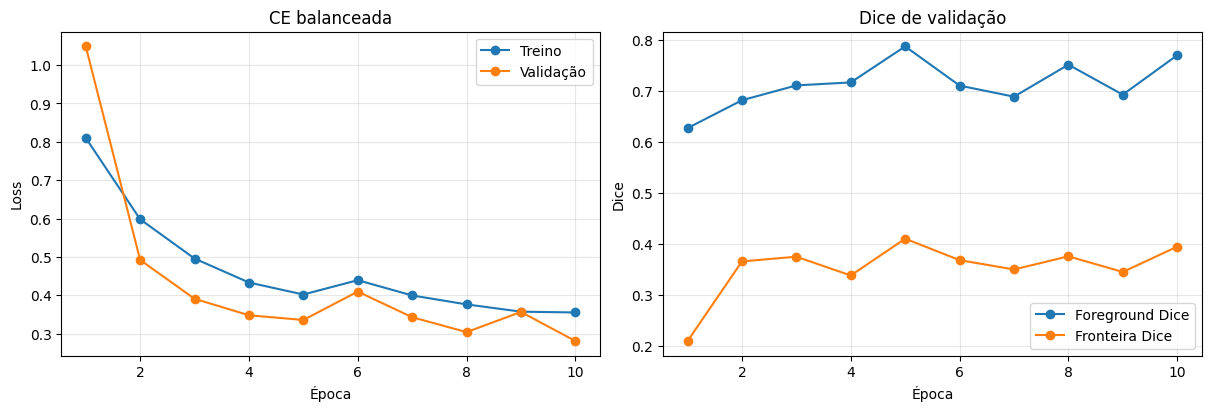

In [47]:
boundary_history_frame = pd.DataFrame(boundary_training_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(boundary_history_frame["epoch"], boundary_history_frame["train_loss"], marker="o", label="Treino")
axes[0].plot(boundary_history_frame["epoch"], boundary_history_frame["val_loss"], marker="o", label="Validação")
axes[0].set_title("CE balanceada")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(boundary_history_frame["epoch"], boundary_history_frame["foreground_dice"], marker="o", label="Foreground Dice")
axes[1].plot(boundary_history_frame["epoch"], boundary_history_frame["boundary_dice"], marker="o", label="Fronteira Dice")
axes[1].set_title("Dice de validação")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Dice")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()

### Decodificação por watershed

A classe interior forma os marcadores. A união de interior e fronteira forma a região de foreground. O watershed expande cada marcador dentro do foreground seguindo o negativo da transformada de distância.

In [48]:
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed


def decode_classes_with_watershed(predicted_classes):
    foreground_mask = predicted_classes != 0
    interior_mask = predicted_classes == 1

    markers, number_of_markers = binary_mask_to_instances(interior_mask)

    # Caso raro: existe foreground, mas nenhum interior foi previsto.
    if number_of_markers == 0:
        fallback_instances, _ = binary_mask_to_instances(foreground_mask)
        return fallback_instances

    distance_map = distance_transform_edt(foreground_mask)
    instance_mask = watershed(
        -distance_map,
        markers=markers,
        mask=foreground_mask,
    )
    return instance_mask.astype(np.int32)


# Teste simples: duas regiões interiores separadas dentro do mesmo foreground.
watershed_test_classes = np.zeros((9, 13), dtype=np.int64)
watershed_test_classes[2:7, 2:11] = 2
watershed_test_classes[3:6, 3:5] = 1
watershed_test_classes[3:6, 8:10] = 1
watershed_test_result = decode_classes_with_watershed(watershed_test_classes)

assert int(watershed_test_result.max()) == 2
print("Teste do watershed: 2 marcadores produziram 2 instâncias.")

Teste do watershed: 2 marcadores produziram 2 instâncias.


### Avaliação final da Parte 2

Com o modelo e a decodificação definidos na validação, avaliamos uma única vez as 101 imagens de teste e comparamos as mesmas métricas com a baseline.

In [49]:
boundary_test_records = []
semantic_dice_sum = 0.0
semantic_iou_sum = 0.0
boundary_model.eval()

for dataset_index in range(len(boundary_test_dataset)):
    sample = boundary_test_dataset[dataset_index]
    image = sample["image"]
    true_foreground = sample["binary_mask"][0].numpy().astype(bool)
    true_instances = sample["instance_mask"].numpy()

    with torch.inference_mode():
        logits = forward_with_padding(
            boundary_model,
            image.unsqueeze(0).to(device),
            
        )
        predicted_classes = logits.argmax(dim=1)[0].cpu().numpy()

    predicted_foreground = predicted_classes != 0
    foreground_dice, foreground_iou = calculate_mask_metrics(
        predicted_foreground,
        true_foreground,
    )
    semantic_dice_sum += foreground_dice
    semantic_iou_sum += foreground_iou

    predicted_instances = decode_classes_with_watershed(predicted_classes)
    instance_metrics = calculate_instance_metrics(
        true_instances,
        predicted_instances,
    )

    catalog_row = test_catalog.iloc[dataset_index]
    boundary_test_records.append(
        {
            "image_id": sample["image_id"],
            "density": catalog_row["instances_per_100k_pixels"],
            "density_bin": catalog_row["density_bin"],
            "map": instance_metrics["map"],
            "count_error": instance_metrics["count_error"],
            "count_bias": instance_metrics["predicted_count"] - instance_metrics["true_count"],
            "true_count": instance_metrics["true_count"],
            "predicted_count": instance_metrics["predicted_count"],
        }
    )

    number_processed = dataset_index + 1
    if number_processed % 20 == 0 or number_processed == len(boundary_test_dataset):
        print(f"Processadas {number_processed}/{len(boundary_test_dataset)} imagens")

boundary_test_results = pd.DataFrame(boundary_test_records)
number_of_test_images = len(boundary_test_dataset)

boundary_semantic_dice = semantic_dice_sum / number_of_test_images
boundary_semantic_iou = semantic_iou_sum / number_of_test_images
boundary_map = boundary_test_results["map"].mean()
boundary_count_mae = boundary_test_results["count_error"].mean()
boundary_count_bias = boundary_test_results["count_bias"].mean()

part_2_comparison = pd.DataFrame(
    {
        "Baseline: binária + CC": {
            "Dice semântico": real_test_metrics["dice"],
            "IoU semântico": real_test_metrics["iou"],
            "mAP de instâncias": baseline_map,
            "Erro absoluto de contagem": baseline_count_mae,
            "Viés de contagem": baseline_count_bias,
        },
        "Parte 2: fronteiras + watershed": {
            "Dice semântico": boundary_semantic_dice,
            "IoU semântico": boundary_semantic_iou,
            "mAP de instâncias": boundary_map,
            "Erro absoluto de contagem": boundary_count_mae,
            "Viés de contagem": boundary_count_bias,
        },
    }
).T

display(part_2_comparison.round(4))

Processadas 20/101 imagens
Processadas 40/101 imagens
Processadas 60/101 imagens
Processadas 80/101 imagens
Processadas 100/101 imagens
Processadas 101/101 imagens


,Dice semântico,IoU semântico,mAP de instâncias,Erro absoluto de contagem,Viés de contagem
Baseline: binária + CC,0.8778,0.7977,0.4318,10.1881,-8.8812
Parte 2: fronteiras + watershed,0.7779,0.6506,0.2264,16.4455,13.4158


### Comparação visual: fronteiras e watershed

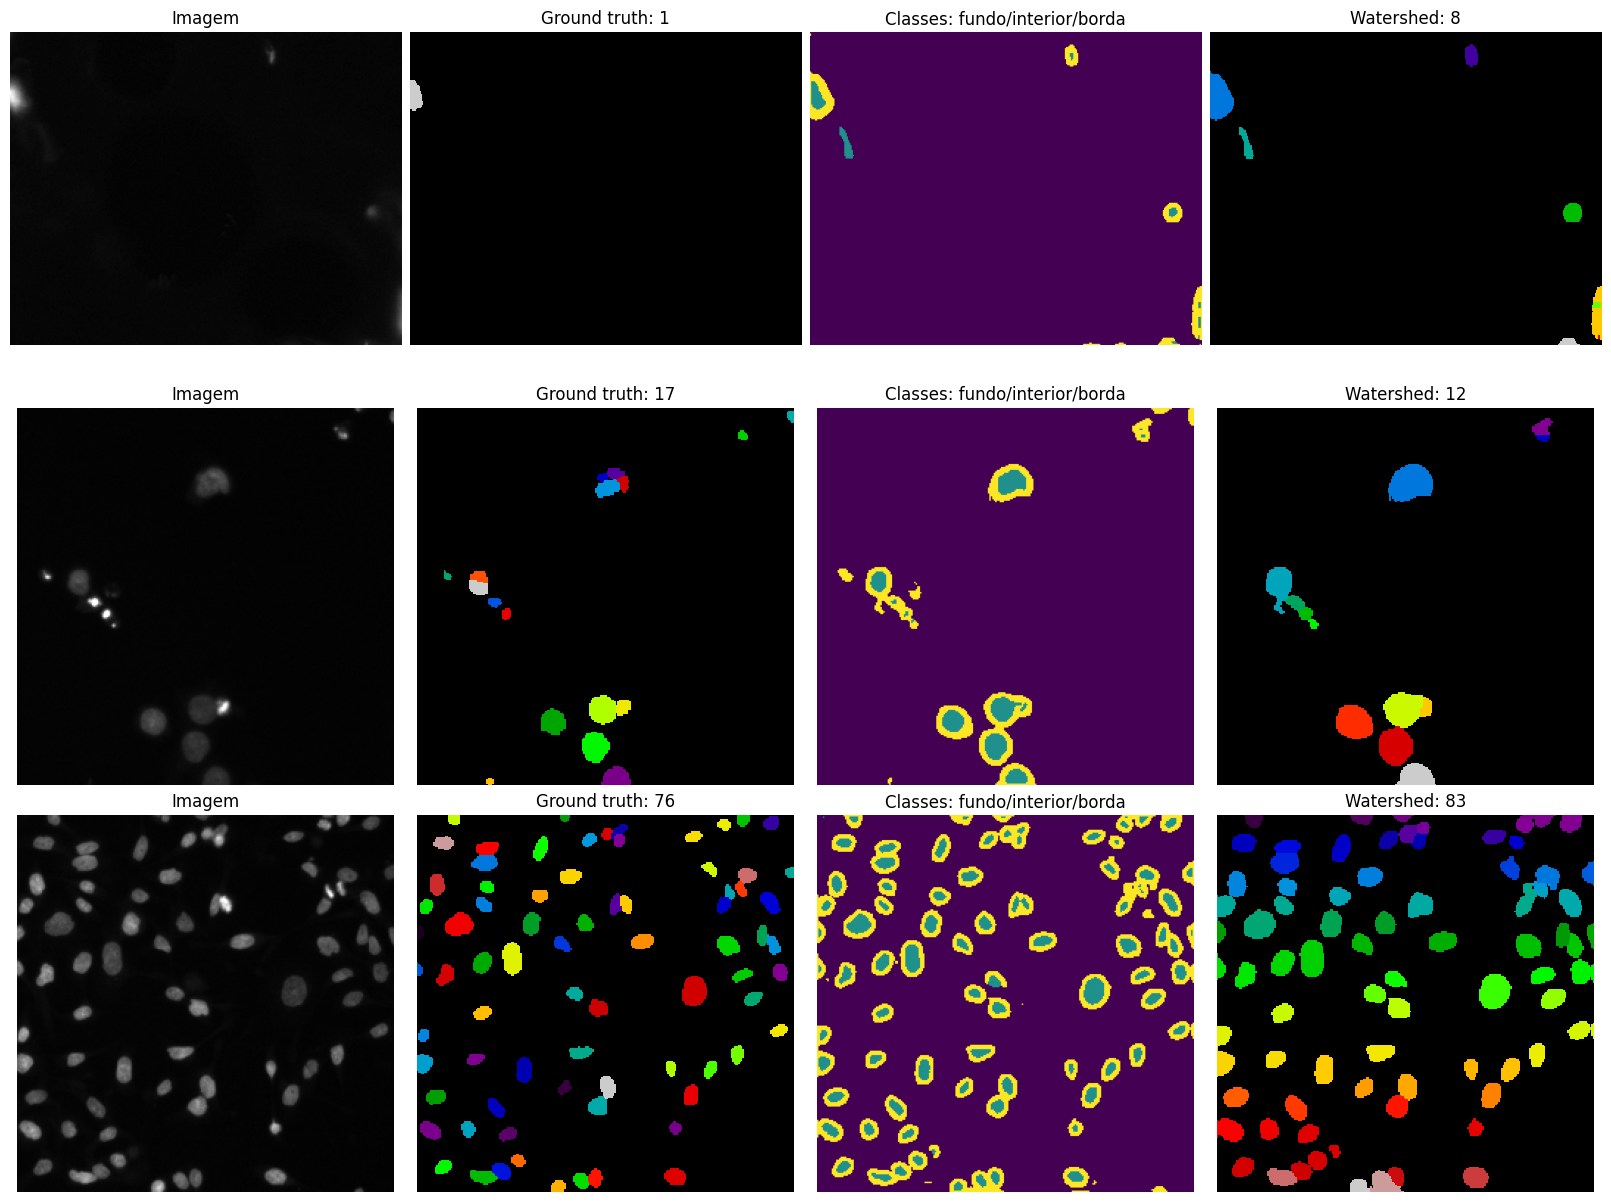

In [50]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12), constrained_layout=True)
boundary_model.eval()

for row, dataset_index in enumerate(selected_indices):
    sample = boundary_test_dataset[dataset_index]
    image = sample["image"]
    true_instances = sample["instance_mask"].numpy()

    with torch.inference_mode():
        logits = forward_with_padding(
            boundary_model,
            image.unsqueeze(0).to(device),
        )
        predicted_classes = logits.argmax(dim=1)[0].cpu().numpy()

    predicted_instances = decode_classes_with_watershed(predicted_classes)

    axes[row, 0].imshow(image[0], cmap="gray")
    axes[row, 0].set_title("Imagem")
    axes[row, 1].imshow(true_instances, cmap="nipy_spectral", interpolation="nearest")
    axes[row, 1].set_title(f"Ground truth: {int(true_instances.max())}")
    axes[row, 2].imshow(predicted_classes, cmap="viridis", vmin=0, vmax=2)
    axes[row, 2].set_title("Classes: fundo/interior/borda")
    axes[row, 3].imshow(predicted_instances, cmap="nipy_spectral", interpolation="nearest")
    axes[row, 3].set_title(f"Watershed: {int(predicted_instances.max())}")

    for axis in axes[row]:
        axis.axis("off")

plt.show()

### Checkpoint da Parte 2

In [51]:
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BOUNDARY_CHECKPOINT_PATH = CHECKPOINT_DIR / "small_unet_boundary_watershed.pt"

torch.save(
    {
        "model_state_dict": boundary_model.state_dict(),
        "in_channels": 1,
        "out_channels": 3,
        "base_channels": 16,
        "class_names": class_names,
        "class_weights": class_weights.tolist(),
        "boundary_thickness": "erosão interna com vizinhança 3x3",
        "learning_rate": REAL_LEARNING_RATE,
        "epochs": BOUNDARY_EPOCHS,
        "split_seed": SPLIT_SEED,
        "train_ids": train_catalog["image_id"].tolist(),
        "val_ids": val_catalog["image_id"].tolist(),
        "test_ids": test_catalog["image_id"].tolist(),
        "training_history": boundary_training_history,
    },
    BOUNDARY_CHECKPOINT_PATH,
)

print(f"Checkpoint salvo em: {BOUNDARY_CHECKPOINT_PATH.resolve()}")

Checkpoint salvo em: C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\checkpoints\small_unet_boundary_watershed.pt


## Parte 2 - correção experimental

A primeira tentativa permanece acima, com suas saídas e o resultado negativo. Nesta seção treinamos outra Small U-Net de três classes com pesos de CE menos agressivos. Escolhemos a época e os parâmetros do watershed apenas na validação; o teste fica para o final. O código da tentativa anterior não precisa ser reexecutado.

### Pesos moderados e decoder

Usamos a raiz quadrada da razão entre a frequência de fundo e a de cada classe. Assim a fronteira continua recebendo peso maior, mas menor que na primeira tentativa. No decoder, regiões interiores minúsculas são descartadas antes de virar marcadores.

In [52]:
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed


def decode_watershed_v2(probabilities, foreground_threshold=0.5,
                        interior_threshold=0.5, minimum_marker_size=16):
    foreground_probability = 1.0 - probabilities[0]
    foreground = foreground_probability >= foreground_threshold
    interior = probabilities[1] >= interior_threshold
    interior = interior & foreground

    markers, _ = binary_mask_to_instances(interior)
    marker_sizes = np.bincount(markers.ravel())

    # Mantemos somente marcadores com área suficiente e renumeramos seus IDs.
    clean_markers = np.zeros(markers.shape, dtype=np.int32)
    next_id = 1
    for marker_id in range(1, len(marker_sizes)):
        if marker_sizes[marker_id] >= minimum_marker_size:
            clean_markers[markers == marker_id] = next_id
            next_id += 1

    if next_id == 1:
        fallback, _ = binary_mask_to_instances(foreground)
        return fallback

    distance = distance_transform_edt(foreground)
    instances = watershed(-distance, markers=clean_markers, mask=foreground)
    return instances.astype(np.int32)


class_counts = torch.zeros(3, dtype=torch.long)
for batch in boundary_train_loader:
    class_counts += torch.bincount(batch["class_mask"].ravel(), minlength=3)

class_frequencies_v2 = class_counts.float() / class_counts.sum()
class_weights_v2 = torch.sqrt(class_frequencies_v2[0] / class_frequencies_v2)
criterion_v2 = nn.CrossEntropyLoss(weight=class_weights_v2.to(device))

for name, frequency, weight in zip(
    ["fundo", "interior", "fronteira"], class_frequencies_v2, class_weights_v2
):
    print(f"{name}: frequência={frequency.item():.4f}, peso={weight.item():.2f}")

# Teste unitário do filtro de marcadores: um pequeno e um grande.
unit_probabilities = np.zeros((3, 12, 20), dtype=np.float32)
unit_probabilities[0] = 1.0
unit_probabilities[0, 2:10, 2:18] = 0.05
unit_probabilities[1, 3:8, 3:8] = 0.90
unit_probabilities[1, 4, 15] = 0.90
unit_instances = decode_watershed_v2(
    unit_probabilities, minimum_marker_size=4
)
assert int(unit_instances.max()) == 1
print("Teste do decoder: marcador de 1 pixel removido.")

fundo: frequência=0.8618, peso=1.00
interior: frequência=0.1091, peso=2.81
fronteira: frequência=0.0291, peso=5.44
Teste do decoder: marcador de 1 pixel removido.


### Treino e seleção da época pelo mAP de validação

O decoder usa parâmetros fixos nesta etapa. Depois de cada época, calculamos o mAP nas 100 imagens de validação. Guardamos os pesos da época com maior mAP. Isso pode demorar mais que a primeira tentativa, pois a validação inclui watershed e matching.

In [53]:
@torch.inference_mode()
def validate_instance_map_v2(model, dataset, decoder_parameters):
    model.eval()
    map_sum = 0.0
    for sample in dataset:
        image = sample["image"].unsqueeze(0).to(device)
        logits = forward_with_padding(model, image)
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
        predicted = decode_watershed_v2(probabilities, **decoder_parameters)
        true_instances = sample["instance_mask"].numpy()
        metrics = calculate_instance_metrics(true_instances, predicted)
        map_sum += metrics["map"]
    return map_sum / len(dataset)


DEFAULT_DECODER_V2 = {
    "foreground_threshold": 0.5,
    "interior_threshold": 0.5,
    "minimum_marker_size": 16,
}

torch.manual_seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
boundary_loader_generator.manual_seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)

boundary_model_v2 = SmallUNet(in_channels=1, out_channels=3,
                              base_channels=16).to(device)
optimizer_v2 = torch.optim.Adam(
    boundary_model_v2.parameters(), lr=REAL_LEARNING_RATE
)
history_v2 = []
best_validation_map_v2 = -1.0
best_model_state_v2 = None
best_epoch_v2 = None
training_start_v2 = time.perf_counter()

for epoch in range(1, 11):
    train_loss = train_boundary_one_epoch(
        boundary_model_v2, boundary_train_loader, optimizer_v2,
        criterion_v2, device
    )
    validation_map = validate_instance_map_v2(
        boundary_model_v2, boundary_val_dataset, DEFAULT_DECODER_V2
    )
    history_v2.append({"epoch": epoch, "train_loss": train_loss,
                       "validation_map": validation_map})

    if validation_map > best_validation_map_v2:
        best_validation_map_v2 = validation_map
        best_model_state_v2 = copy.deepcopy(boundary_model_v2.state_dict())
        best_epoch_v2 = epoch

    print(f"Época {epoch:02d}/10 | loss={train_loss:.4f} | "
          f"mAP validação={validation_map:.4f}")

assert best_model_state_v2 is not None
boundary_model_v2.load_state_dict(best_model_state_v2)
print(f"Melhor época: {best_epoch_v2}; mAP={best_validation_map_v2:.4f}")
print(f"Tempo: {(time.perf_counter()-training_start_v2)/60:.2f} min")

Época 01/10 | loss=0.8164 | mAP validação=0.1530
Época 02/10 | loss=0.5444 | mAP validação=0.2048
Época 03/10 | loss=0.4162 | mAP validação=0.2855
Época 04/10 | loss=0.3661 | mAP validação=0.2649
Época 05/10 | loss=0.3165 | mAP validação=0.3289
Época 06/10 | loss=0.3023 | mAP validação=0.3470
Época 07/10 | loss=0.2911 | mAP validação=0.2878
Época 08/10 | loss=0.2788 | mAP validação=0.4159
Época 09/10 | loss=0.2652 | mAP validação=0.3565
Época 10/10 | loss=0.2540 | mAP validação=0.4026
Melhor época: 8; mAP=0.4159
Tempo: 2.97 min


### Calibração do watershed somente na validação

Testamos uma grade pequena de limiares e tamanhos mínimos, sem consultar as imagens de teste. O melhor mAP escolhe os parâmetros; em empate, vence o menor erro de contagem.

In [56]:
validation_predictions_v2 = []
boundary_model_v2.eval()
for sample in boundary_val_dataset:
    image = sample["image"].unsqueeze(0).to(device)
    with torch.inference_mode():
        logits = forward_with_padding(boundary_model_v2, image)
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
    validation_predictions_v2.append(
        (probabilities.astype(np.float16), sample["instance_mask"].numpy())
    )

calibration_rows_v2 = []
for foreground_threshold in [0.5, 0.6, 0.7]:
    for interior_threshold in [0.4, 0.5, 0.6]:
        for minimum_marker_size in [8, 16, 32]:
            map_sum = 0.0
            count_error_sum = 0.0
            for probabilities, true_instances in validation_predictions_v2:
                predicted = decode_watershed_v2(
                    probabilities, foreground_threshold,
                    interior_threshold, minimum_marker_size
                )
                metrics = calculate_instance_metrics(true_instances, predicted)
                map_sum += metrics["map"]
                count_error_sum += metrics["count_error"]

            calibration_rows_v2.append({
                "foreground_threshold": foreground_threshold,
                "interior_threshold": interior_threshold,
                "minimum_marker_size": minimum_marker_size,
                "validation_map": map_sum / len(validation_predictions_v2),
                "count_mae": count_error_sum / len(validation_predictions_v2),
            })

calibration_v2 = pd.DataFrame(calibration_rows_v2)
calibration_v2 = calibration_v2.sort_values(
    ["validation_map", "count_mae"], ascending=[False, True]
).reset_index(drop=True)
best_row_v2 = calibration_v2.iloc[0]
best_decoder_v2 = {
    "foreground_threshold": float(best_row_v2["foreground_threshold"]),
    "interior_threshold": float(best_row_v2["interior_threshold"]),
    "minimum_marker_size": int(best_row_v2["minimum_marker_size"]),
}
display(calibration_v2.head().round(4))
print("Decoder escolhido na validação:", best_decoder_v2)

,foreground_threshold,interior_threshold,minimum_marker_size,validation_map,count_mae
0,0.7,0.6,8,0.4648,11.55
1,0.7,0.6,16,0.4613,11.42
2,0.7,0.5,8,0.4560,12.36
3,0.7,0.5,16,0.4548,11.76
4,0.6,0.6,8,0.4543,11.52


Decoder escolhido na validação: {'foreground_threshold': 0.7, 'interior_threshold': 0.6, 'minimum_marker_size': 8}


### Comparação final no teste

Somente depois de fixar época e decoder pela validação, avaliamos as 101 imagens de teste. Também salvamos um novo checkpoint; o arquivo da primeira tentativa permanece intacto.

In [ ]:
test_records_v2 = []
semantic_dice_sum_v2 = 0.0
semantic_iou_sum_v2 = 0.0
boundary_model_v2.eval()

for index, sample in enumerate(boundary_test_dataset):
    image = sample["image"].unsqueeze(0).to(device)
    with torch.inference_mode():
        logits = forward_with_padding(boundary_model_v2, image)
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()

    predicted_foreground = (
        1.0 - probabilities[0] >= best_decoder_v2["foreground_threshold"]
    )
    true_foreground = sample["binary_mask"][0].numpy().astype(bool)
    dice, iou = calculate_mask_metrics(
        torch.from_numpy(predicted_foreground),
        torch.from_numpy(true_foreground),
    )
    semantic_dice_sum_v2 += dice
    semantic_iou_sum_v2 += iou

    predicted_instances = decode_watershed_v2(probabilities, **best_decoder_v2)
    true_instances = sample["instance_mask"].numpy()
    metrics = calculate_instance_metrics(true_instances, predicted_instances)
    test_records_v2.append({
        "image_id": sample["image_id"],
        "map": metrics["map"],
        "count_error": metrics["count_error"],
        "count_bias": metrics["predicted_count"] - metrics["true_count"],
    })
    if (index + 1) % 20 == 0:
        print(f"Processadas {index + 1}/{len(boundary_test_dataset)}")

test_results_v2 = pd.DataFrame(test_records_v2)
comparison_v2 = pd.DataFrame({
    "Baseline binária + CC": {
        "Dice": real_test_metrics["dice"],
        "IoU": real_test_metrics["iou"],
        "mAP": baseline_map,
        "Erro médio de contagem": baseline_count_mae,
        "Viés de contagem": baseline_count_bias,
    },
    "Parte 2 corrigida": {
        "Dice": semantic_dice_sum_v2 / len(boundary_test_dataset),
        "IoU": semantic_iou_sum_v2 / len(boundary_test_dataset),
        "mAP": test_results_v2["map"].mean(),
        "Erro médio de contagem": test_results_v2["count_error"].mean(),
        "Viés de contagem": test_results_v2["count_bias"].mean(),
    },
}).T
display(comparison_v2.round(4))

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_v2 = CHECKPOINT_DIR / "small_unet_boundary_watershed_v2.pt"
torch.save({
    "model_state_dict": boundary_model_v2.state_dict(),
    "class_weights": class_weights_v2.tolist(),
    "decoder_parameters": best_decoder_v2,
    "best_epoch": best_epoch_v2,
    "best_validation_map": best_validation_map_v2,
    "split_seed": SPLIT_SEED,
    "history": history_v2,
}, checkpoint_v2)
print("Novo checkpoint:", checkpoint_v2.resolve())

Processadas 20/101
Processadas 40/101
Processadas 60/101
Processadas 80/101
Processadas 100/101


,Dice,IoU,mAP,Erro médio de contagem,Viés de contagem
Baseline binária + CC,0.8869,0.8108,0.4465,10.7426,-9.3564
Parte 2 corrigida,0.8850,0.8076,0.4661,9.8911,-8.3861


Novo checkpoint: C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\checkpoints\small_unet_boundary_watershed_v2.pt


### Experimento complementar — duração do treino (10 versus 20 épocas)

Pergunta: o limite de 10 épocas impediu a SmallUNet de melhorar? A célula abaixo **reinicia o treino do zero** com a mesma seed, split, arquitetura, CE balanceada, learning rate e regra de escolha da melhor época da Parte 2; muda apenas o limite para 20 épocas. Assim, não confundimos mais épocas com uma nova arquitetura.

A seleção da época continua usando mAP da **validação** com o decoder provisório da Parte 2. Guardamos o melhor modelo até a época 10 e o melhor até a época 20 **na mesma execução**, evitando confundir mais épocas com variações entre treinos. Depois, comparamos os dois checkpoints na mesma validação e com o decoder já fixado no checkpoint atual. O conjunto de teste não participa desta decisão. Os novos checkpoints e CSVs têm nomes próprios; `small_unet_boundary_watershed_v2.pt` não é substituído.

A flag está em `True` para a execução combinada na máquina com GPU. Rode antes as células de preparação e funções de treino da Parte 2 **no mesmo kernel** e execute só a célula seguinte. Ela não é incluída por `train.py`. Não use “Executar tudo” só para este teste, pois isso repetiria os treinos antigos. Depois, volte a flag para `False` se quiser abrir o notebook sem iniciar esse treino.

Época 01/20: loss=0.8182; mAP validação=0.1463
Época 02/20: loss=0.5362; mAP validação=0.2177
Época 03/20: loss=0.4199; mAP validação=0.2063
Época 04/20: loss=0.3580; mAP validação=0.2607
Época 05/20: loss=0.3189; mAP validação=0.3571
Época 06/20: loss=0.2997; mAP validação=0.3459
Época 07/20: loss=0.2898; mAP validação=0.3237
Época 08/20: loss=0.2942; mAP validação=0.4245
Época 09/20: loss=0.2668; mAP validação=0.3714
Época 10/20: loss=0.2558; mAP validação=0.3781
Época 11/20: loss=0.2488; mAP validação=0.4149
Época 12/20: loss=0.2462; mAP validação=0.4160
Época 13/20: loss=0.2701; mAP validação=0.3600
Época 14/20: loss=0.2574; mAP validação=0.3827
Época 15/20: loss=0.2326; mAP validação=0.4563
Época 16/20: loss=0.2367; mAP validação=0.3822
Época 17/20: loss=0.2353; mAP validação=0.4197
Época 18/20: loss=0.2504; mAP validação=0.4428
Época 19/20: loss=0.2363; mAP validação=0.4161
Época 20/20: loss=0.2221; mAP validação=0.4425


,modelo,map_validacao,erro_contagem
0,até 10 épocas (controle),0.4522,11.37
1,até 20 épocas (novo treino),0.4825,10.99


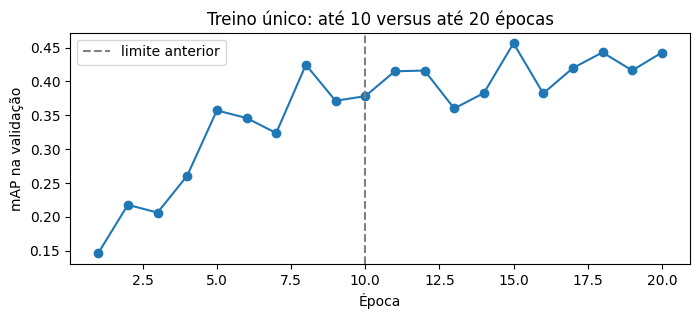

Melhor época: 15
Arquivos separados: checkpoints\small_unet_boundary_10ep_control.pt checkpoints\small_unet_boundary_20ep.pt results\part2_20ep_history.csv results\part2_20ep_validation.csv
Não avaliamos o teste: primeiro decida pela validação.


In [55]:
from copy import deepcopy
import matplotlib.pyplot as plt

RUN_20_EPOCH_EXPERIMENT = True  # Executar somente na máquina com GPU.
LONG_EPOCHS = 20
TEN_CONTROL_CHECKPOINT = Path("checkpoints/small_unet_boundary_10ep_control.pt")
LONG_CHECKPOINT = Path("checkpoints/small_unet_boundary_20ep.pt")
LONG_HISTORY = Path("results/part2_20ep_history.csv")
LONG_COMPARISON = Path("results/part2_20ep_validation.csv")

if RUN_20_EPOCH_EXPERIMENT:
    if not torch.cuda.is_available():
        raise RuntimeError("Este treino longo foi reservado para a máquina com GPU CUDA.")
    needed = ["boundary_train_loader", "boundary_val_dataset",
              "train_boundary_one_epoch", "validate_instance_map_v2",
              "DEFAULT_DECODER_V2", "boundary_loader_generator"]
    missing = [name for name in needed if name not in globals()]
    if missing:
        raise RuntimeError(f"Execute antes a preparação da Parte 2: {missing}")
    reference_path = Path("checkpoints/small_unet_boundary_watershed_v2.pt")
    if not reference_path.is_file():
        raise FileNotFoundError(f"Checkpoint original não encontrado: {reference_path}")
    reference = torch.load(reference_path, map_location="cpu", weights_only=True)
    fixed_decoder = reference["decoder_parameters"]
    # Usamos os pesos de classe salvos com o checkpoint original.
    longer_weights = torch.tensor(reference["class_weights"],
                                  dtype=torch.float32, device=device)
    longer_criterion = nn.CrossEntropyLoss(weight=longer_weights)

    # A seed e as demais escolhas repetem as da Parte 2.
    torch.manual_seed(SPLIT_SEED)
    np.random.seed(SPLIT_SEED)
    boundary_loader_generator.manual_seed(SPLIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SPLIT_SEED)
    longer_model = SmallUNet(in_channels=1, out_channels=3,
                             base_channels=16).to(device)
    longer_optimizer = torch.optim.Adam(
        longer_model.parameters(), lr=REAL_LEARNING_RATE
    )
    best_map, best_epoch, best_state = -1.0, None, None
    longer_history = []
    ten_state, ten_epoch = None, None
    LONG_CHECKPOINT.parent.mkdir(exist_ok=True)
    LONG_HISTORY.parent.mkdir(exist_ok=True)

    for epoch in range(1, LONG_EPOCHS + 1):
        loss = train_boundary_one_epoch(longer_model, boundary_train_loader,
                                        longer_optimizer, longer_criterion, device)
        validation_map = validate_instance_map_v2(
            longer_model, boundary_val_dataset, DEFAULT_DECODER_V2
        )
        longer_history.append({"epoch": epoch, "train_loss": loss,
                               "validation_map": validation_map})
        if validation_map > best_map:
            best_map, best_epoch = validation_map, epoch
            best_state = deepcopy(longer_model.state_dict())
            # Preserva o melhor modelo mesmo se a sessão de GPU for interrompida.
            torch.save({"model_state_dict": best_state,
                        "decoder_parameters": fixed_decoder,
                        "class_weights": reference["class_weights"],
                        "best_epoch": best_epoch,
                        "best_validation_map_selection": best_map,
                        "split_seed": SPLIT_SEED,
                        "max_epochs": LONG_EPOCHS}, LONG_CHECKPOINT)
        pd.DataFrame(longer_history).to_csv(LONG_HISTORY, index=False)
        if epoch == 10:
            # Controle: melhor checkpoint encontrado nas dez primeiras épocas.
            ten_state, ten_epoch = deepcopy(best_state), best_epoch
            torch.save({"model_state_dict": ten_state,
                        "decoder_parameters": fixed_decoder,
                        "class_weights": reference["class_weights"],
                        "best_epoch": ten_epoch,
                        "split_seed": SPLIT_SEED,
                        "max_epochs": 10}, TEN_CONTROL_CHECKPOINT)
        print(f"Época {epoch:02d}/{LONG_EPOCHS}: loss={loss:.4f}; "
              f"mAP validação={validation_map:.4f}")

    longer_model.load_state_dict(best_state)
    longer_model.eval()
    control_model = SmallUNet(in_channels=1, out_channels=3,
                              base_channels=16).to(device)
    control_model.load_state_dict(ten_state)
    control_model.eval()

    # Comparação justa: as mesmas imagens e o mesmo decoder fixo, só validação.
    from pa1_experiments import (build_catalog, evaluate_ids,
                                  find_data_root, split_catalog)
    data_root_long = find_data_root(Path("data/BBBC038"))
    _, validation_catalog, _ = split_catalog(
        build_catalog(data_root_long), seed=SPLIT_SEED
    )
    validation_ids = validation_catalog["image_id"].tolist()
    original_rows = evaluate_ids(data_root_long, validation_ids, control_model,
                                 fixed_decoder, device)
    longer_rows = evaluate_ids(data_root_long, validation_ids, longer_model,
                               fixed_decoder, device)
    comparison_long = pd.DataFrame([
        {"modelo": "até 10 épocas (controle)",
         "map_validacao": original_rows["map"].mean(),
         "erro_contagem": original_rows["count_error"].mean()},
        {"modelo": "até 20 épocas (novo treino)",
         "map_validacao": longer_rows["map"].mean(),
         "erro_contagem": longer_rows["count_error"].mean()},
    ])
    comparison_long.to_csv(LONG_COMPARISON, index=False)
    torch.save({"model_state_dict": best_state,
                "decoder_parameters": fixed_decoder,
                "class_weights": reference["class_weights"],
                "best_epoch": best_epoch,
                "best_validation_map_selection": best_map,
                "split_seed": SPLIT_SEED,
                "max_epochs": LONG_EPOCHS,
                "history": longer_history}, LONG_CHECKPOINT)
    display(comparison_long.round(4))
    plt.figure(figsize=(8, 3))
    plt.plot([row["epoch"] for row in longer_history],
             [row["validation_map"] for row in longer_history], marker="o")
    plt.axvline(10, color="gray", linestyle="--", label="limite anterior")
    plt.xlabel("Época")
    plt.ylabel("mAP na validação")
    plt.title("Treino único: até 10 versus até 20 épocas")
    plt.legend()
    plt.show()
    print("Melhor época:", best_epoch)
    print("Arquivos separados:", TEN_CONTROL_CHECKPOINT, LONG_CHECKPOINT,
          LONG_HISTORY, LONG_COMPARISON)
    print("Não avaliamos o teste: primeiro decida pela validação.")
else:
    print("Experimento de 20 épocas não executado. Ative a flag na GPU.")

## Parte 3 - Ablações em dois eixos

Vamos estudar a função de perda (eixo 2) e o contexto global (eixo 3). Cada configuração usa duas seeds, o mesmo split e o mesmo número de épocas. Medimos mAP de instâncias e Dice semântico **na validação**, sem usar o teste para escolher modelos. O decoder fica fixo com os parâmetros escolhidos na Parte 2; assim, a comparação isola a mudança de loss ou de contexto.

As 8 configurações de loss x 2 seeds exigem 16 treinos. Para contexto global, reaproveitamos as duas execuções da focal balanceada com gamma=2 como controle sem contexto e treinamos mais duas com image pooling. Portanto, são **18 treinos de 6 épocas**. Pode levar mais de uma hora na GPU; as células salvam resultados parciais após cada configuração.

### Loss focal e bloco de contexto global

Para `gamma=0`, focal é exatamente CE; com pesos de classe, é CE balanceada. Com `gamma>0`, pixels já fáceis recebem menos importância. O bloco de contexto faz média global do mapa no gargalo da U-Net e devolve essa informação a todas as posições. O restante do encoder-decoder não muda.

In [ ]:
import torch.nn.functional as F


class FocalCrossEntropy(nn.Module):
    def __init__(self, gamma, class_weights=None):
        super().__init__()
        self.gamma = gamma
        if class_weights is None:
            self.register_buffer("class_weights", None)
        else:
            self.register_buffer("class_weights", class_weights.float().clone())

    def forward(self, logits, targets):
        log_probabilities = F.log_softmax(logits, dim=1)
        true_log_probability = log_probabilities.gather(
            1, targets.unsqueeze(1)
        ).squeeze(1)
        true_probability = true_log_probability.exp()

        pixel_loss = -true_log_probability
        pixel_loss = (1 - true_probability) ** self.gamma * pixel_loss

        if self.class_weights is None:
            return pixel_loss.mean()

        pixel_weights = self.class_weights[targets]
        return (pixel_loss * pixel_weights).sum() / pixel_weights.sum()


class UNetWithImagePooling(SmallUNet):
    def __init__(self, in_channels=1, out_channels=3, base_channels=16):
        super().__init__(in_channels, out_channels, base_channels)
        bottleneck_channels = base_channels * 8
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.context_conv = nn.Conv2d(
            bottleneck_channels, bottleneck_channels, kernel_size=1
        )

    def forward(self, x):
        skip1 = self.enc1(x)
        skip2 = self.enc2(self.pool(skip1))
        skip3 = self.enc3(self.pool(skip2))
        x = self.bottleneck(self.pool(skip3))

        # O mapa 1x1 é expandido automaticamente ao somar com o gargalo.
        global_context = self.global_pool(x)
        global_context = self.context_conv(global_context)
        x = x + global_context

        x = self.up3(x)
        x = self.dec3(torch.cat([x, skip3], dim=1))
        x = self.up2(x)
        x = self.dec2(torch.cat([x, skip2], dim=1))
        x = self.up1(x)
        x = self.dec1(torch.cat([x, skip1], dim=1))
        return self.head(x)


# Gamma zero deve coincidir numericamente com CrossEntropyLoss.
unit_logits = torch.tensor([[[[2.0, 0.1]], [[0.5, 2.0]], [[-1.0, -0.5]]]])
unit_targets = torch.tensor([[[0, 1]]])
unit_focal = FocalCrossEntropy(gamma=0)(unit_logits, unit_targets)
unit_ce = nn.CrossEntropyLoss()(unit_logits, unit_targets)
assert torch.allclose(unit_focal, unit_ce)

unit_weights = torch.tensor([1.0, 2.0, 5.0])
unit_balanced_focal = FocalCrossEntropy(0, unit_weights)(
    unit_logits, unit_targets
)
unit_balanced_ce = nn.CrossEntropyLoss(weight=unit_weights)(
    unit_logits, unit_targets
)
assert torch.allclose(unit_balanced_focal, unit_balanced_ce)

test_context_model = UNetWithImagePooling().to(device)
with torch.inference_mode():
    test_context_output = test_context_model(
        torch.zeros(1, 1, 256, 256, device=device)
    )
assert test_context_output.shape == (1, 3, 256, 256)
del test_context_model, test_context_output
print("Focal gamma=0 = CE; modelo com contexto produz 3 mapas de 256x256.")

Focal gamma=0 = CE; modelo com contexto produz 3 mapas de 256x256.


### Protocolo comum dos experimentos

Em cada treino, a seed controla a inicialização e a ordem dos crops. Escolhemos a melhor época pelo mAP de validação. Para evitar que uma execução longa se perca, cada resultado é gravado em CSV logo após terminar; se a célula for interrompida, ela pode ser executada novamente e pula as configurações já registradas.

In [ ]:
ABLATION_SEEDS = [42, 123]
ABLATION_EPOCHS = 6
ABLATION_RESULTS_DIR = Path("results")
ABLATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LOSS_RESULTS_PATH = ABLATION_RESULTS_DIR / "part3_loss_runs.csv"
CONTEXT_RESULTS_PATH = ABLATION_RESULTS_DIR / "part3_context_runs.csv"


@torch.inference_mode()
def evaluate_ablation(model, dataset):
    model.eval()
    map_sum = 0.0
    foreground_dice_sum = 0.0
    boundary_dice_sum = 0.0

    for sample in dataset:
        image = sample["image"].unsqueeze(0).to(device)
        logits = forward_with_padding(model, image)
        probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()

        predicted_instances = decode_watershed_v2(
            probabilities, **best_decoder_v2
        )
        true_instances = sample["instance_mask"].numpy()
        instance_metrics = calculate_instance_metrics(
            true_instances, predicted_instances
        )
        map_sum += instance_metrics["map"]

        predicted_foreground = (
            1 - probabilities[0] >= best_decoder_v2["foreground_threshold"]
        )
        true_foreground = sample["binary_mask"][0].numpy().astype(bool)
        foreground_dice, _ = calculate_mask_metrics(
            torch.from_numpy(predicted_foreground),
            torch.from_numpy(true_foreground),
        )
        foreground_dice_sum += foreground_dice

        predicted_boundary = probabilities.argmax(axis=0) == 2
        true_boundary = sample["boundary_mask"][0].numpy().astype(bool)
        boundary_dice, _ = calculate_mask_metrics(
            torch.from_numpy(predicted_boundary),
            torch.from_numpy(true_boundary),
        )
        boundary_dice_sum += boundary_dice

    number_of_images = len(dataset)
    return {
        "val_map": map_sum / number_of_images,
        "val_dice": foreground_dice_sum / number_of_images,
        "val_boundary_dice": boundary_dice_sum / number_of_images,
    }


def run_ablation(config_name, seed, gamma, balanced, global_context):
    torch.manual_seed(seed)
    np.random.seed(seed)
    boundary_loader_generator.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if global_context:
        model = UNetWithImagePooling().to(device)
    else:
        model = SmallUNet(in_channels=1, out_channels=3,
                          base_channels=16).to(device)

    weights = class_weights_v2 if balanced else None
    criterion = FocalCrossEntropy(gamma, weights).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=REAL_LEARNING_RATE)

    best_metrics = None
    best_epoch = None
    run_start = time.perf_counter()

    for epoch in range(1, ABLATION_EPOCHS + 1):
        train_loss = train_boundary_one_epoch(
            model, boundary_train_loader, optimizer, criterion, device
        )
        metrics = evaluate_ablation(model, boundary_val_dataset)
        if best_metrics is None or metrics["val_map"] > best_metrics["val_map"]:
            best_metrics = metrics.copy()
            best_epoch = epoch

        print(
            f"{config_name} | seed {seed} | época {epoch}/{ABLATION_EPOCHS} "
            f"| loss {train_loss:.4f} | mAP val {metrics['val_map']:.4f}"
        )

    result = {
        "config": config_name,
        "seed": seed,
        "gamma": gamma,
        "balanced": balanced,
        "global_context": global_context,
        "best_epoch": best_epoch,
        "duration_min": (time.perf_counter() - run_start) / 60,
    }
    result.update(best_metrics)
    return result


def load_run_results(path):
    if path.exists():
        return pd.read_csv(path).to_dict("records")
    return []


def run_already_recorded(records, config_name, seed):
    for record in records:
        if record["config"] == config_name and int(record["seed"]) == seed:
            return True
    return False


print("Seeds:", ABLATION_SEEDS)
print("Épocas por treino:", ABLATION_EPOCHS)
print("Decoder fixo:", best_decoder_v2)

Seeds: [42, 123]
Épocas por treino: 6
Decoder fixo: {'foreground_threshold': 0.6, 'interior_threshold': 0.6, 'minimum_marker_size': 8}


### Eixo 2 - oito configurações de loss, duas seeds

Esta célula inicia **16 treinos**. Gamma zero representa CE, com ou sem pesos. Os demais valores são focal, também com ou sem pesos. Ela pode demorar cerca de uma hora ou mais; observe o progresso e mantenha a GPU conectada.

In [ ]:
loss_run_records = load_run_results(LOSS_RESULTS_PATH)

for balanced in [False, True]:
    for gamma in [0, 1, 2, 5]:
        if gamma == 0:
            config_name = "CE balanceada" if balanced else "CE"
        else:
            prefix = "Focal balanceada" if balanced else "Focal"
            config_name = f"{prefix} gamma={gamma}"

        for seed in ABLATION_SEEDS:
            if run_already_recorded(loss_run_records, config_name, seed):
                print(f"Já registrado: {config_name}, seed {seed}")
                continue

            result = run_ablation(
                config_name, seed, gamma, balanced, global_context=False
            )
            loss_run_records.append(result)
            pd.DataFrame(loss_run_records).to_csv(LOSS_RESULTS_PATH, index=False)

print(f"Concluídos {len(loss_run_records)}/16 treinos de loss.")
print("Resultados parciais:", LOSS_RESULTS_PATH.resolve())

Já registrado: CE, seed 42
Já registrado: CE, seed 123
Já registrado: Focal gamma=1, seed 42
Já registrado: Focal gamma=1, seed 123
Já registrado: Focal gamma=2, seed 42
Já registrado: Focal gamma=2, seed 123
Já registrado: Focal gamma=5, seed 42
Já registrado: Focal gamma=5, seed 123
Já registrado: CE balanceada, seed 42
Já registrado: CE balanceada, seed 123
Já registrado: Focal balanceada gamma=1, seed 42
Já registrado: Focal balanceada gamma=1, seed 123
Já registrado: Focal balanceada gamma=2, seed 42
Já registrado: Focal balanceada gamma=2, seed 123
Já registrado: Focal balanceada gamma=5, seed 42
Já registrado: Focal balanceada gamma=5, seed 123
Concluídos 16/16 treinos de loss.
Resultados parciais: C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\results\part3_loss_runs.csv


### Efeito da loss e do gamma

Reportamos média e desvio amostral das duas seeds. O gráfico mostra separadamente os resultados com e sem pesos de classe, para avaliar se a focal reduz o problema do desbalanceamento de fronteira.

,balanced,gamma,config,map_mean,map_std,dice_mean,dice_std,boundary_dice_mean,boundary_dice_std
0,False,0,CE,0.3258,0.0379,0.7704,0.0646,0.0414,0.0585
1,False,1,Focal gamma=1,0.3448,0.0423,0.8021,0.0433,0.1368,0.1824
2,False,2,Focal gamma=2,0.3572,0.0406,0.7918,0.0506,0.2521,0.0510
3,False,5,Focal gamma=5,0.3170,0.0061,0.8352,0.0008,0.2945,0.1150
4,True,0,CE balanceada,0.3964,0.0101,0.8529,0.0036,0.4921,0.0036
5,True,1,Focal balanceada gamma=1,0.4133,0.0214,0.8591,0.0059,0.5044,0.0114
6,True,2,Focal balanceada gamma=2,0.3759,0.0499,0.8333,0.0059,0.4612,0.0478
7,True,5,Focal balanceada gamma=5,0.3116,0.0213,0.8145,0.0390,0.4754,0.0127


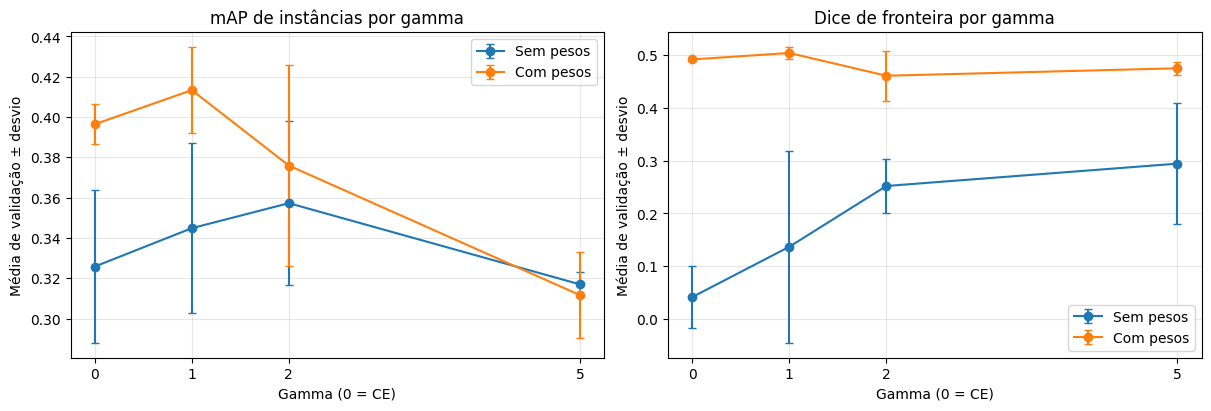

In [ ]:
loss_results = pd.read_csv(LOSS_RESULTS_PATH)
assert len(loss_results) == 16, "Execute todos os 16 treinos antes do resumo."

loss_summary = loss_results.groupby(
    ["balanced", "gamma", "config"], as_index=False
).agg(
    map_mean=("val_map", "mean"),
    map_std=("val_map", "std"),
    dice_mean=("val_dice", "mean"),
    dice_std=("val_dice", "std"),
    boundary_dice_mean=("val_boundary_dice", "mean"),
    boundary_dice_std=("val_boundary_dice", "std"),
)

display(loss_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for balanced in [False, True]:
    group = loss_summary[loss_summary["balanced"] == balanced]
    legend_label = "Com pesos" if balanced else "Sem pesos"
    axes[0].errorbar(group["gamma"], group["map_mean"],
                     yerr=group["map_std"], marker="o", capsize=3, label=legend_label)
    axes[1].errorbar(group["gamma"], group["boundary_dice_mean"],
                     yerr=group["boundary_dice_std"], marker="o", capsize=3,
                     label=legend_label)

axes[0].set_title("mAP de instâncias por gamma")
axes[1].set_title("Dice de fronteira por gamma")
for axis in axes:
    axis.set_xlabel("Gamma (0 = CE)")
    axis.set_ylabel("Média de validação ± desvio")
    axis.set_xticks([0, 1, 2, 5])
    axis.legend()
    axis.grid(alpha=0.3)
plt.show()


### Eixo 3 - contexto global, duas seeds

Usamos focal balanceada `gamma=2` como configuração fixa e comparamos a U-Net original com a mesma U-Net acrescida de image pooling global no gargalo. Os dois controles sem pooling já foram treinados no eixo 2; esta célula executa apenas os **dois treinos adicionais**.

In [ ]:
loss_results = pd.read_csv(LOSS_RESULTS_PATH)
control_name = "Focal balanceada gamma=2"
control_rows = loss_results[loss_results["config"] == control_name]
assert len(control_rows) == 2, "Faltam as duas seeds do controle no eixo 2."

context_run_records = load_run_results(CONTEXT_RESULTS_PATH)
context_name = "Focal balanceada gamma=2 + image pooling"

for seed in ABLATION_SEEDS:
    if run_already_recorded(context_run_records, context_name, seed):
        print(f"Já registrado: contexto global, seed {seed}")
        continue

    result = run_ablation(
        context_name, seed, gamma=2, balanced=True, global_context=True
    )
    context_run_records.append(result)
    pd.DataFrame(context_run_records).to_csv(
        CONTEXT_RESULTS_PATH, index=False
    )

print(f"Concluídos {len(context_run_records)}/2 treinos com contexto.")

Já registrado: contexto global, seed 42
Já registrado: contexto global, seed 123
Concluídos 2/2 treinos com contexto.


### Comparação final da Parte 3

A tabela usa sempre as mesmas duas seeds. O mAP responde à separação de instâncias; Dice de foreground e de fronteira ajudam a verificar se o contexto melhora apenas a classificação dos pixels ou também a separação dos objetos.

In [ ]:
loss_results = pd.read_csv(LOSS_RESULTS_PATH)
context_results = pd.read_csv(CONTEXT_RESULTS_PATH)

control_rows = loss_results[
    loss_results["config"] == "Focal balanceada gamma=2"
].copy()
context_rows = context_results.copy()
assert len(control_rows) == 2 and len(context_rows) == 2
assert set(control_rows["seed"]) == set(context_rows["seed"])

control_rows["contexto"] = "Sem image pooling"
context_rows["contexto"] = "Com image pooling"
comparison_rows = pd.concat([control_rows, context_rows], ignore_index=True)

context_summary = comparison_rows.groupby("contexto").agg(
    map_mean=("val_map", "mean"),
    map_std=("val_map", "std"),
    dice_mean=("val_dice", "mean"),
    dice_std=("val_dice", "std"),
    boundary_dice_mean=("val_boundary_dice", "mean"),
    boundary_dice_std=("val_boundary_dice", "std"),
)
display(context_summary.round(4))

map_change = (
    context_summary.loc["Com image pooling", "map_mean"]
    - context_summary.loc["Sem image pooling", "map_mean"]
)
dice_change = (
    context_summary.loc["Com image pooling", "dice_mean"]
    - context_summary.loc["Sem image pooling", "dice_mean"]
)
print(f"Variação média do mAP: {map_change:+.4f}")
print(f"Variação média do Dice semântico: {dice_change:+.4f}")
print("Interprete essas diferenças junto com os desvios das duas seeds.")

,map_mean,map_std,dice_mean,dice_std,boundary_dice_mean,boundary_dice_std
contexto,,,,,,
Com image pooling,0.4278,0.0370,0.8255,0.0162,0.4853,0.0220
Sem image pooling,0.3759,0.0499,0.8333,0.0059,0.4612,0.0478


Variação média do mAP: +0.0519
Variação média do Dice semântico: -0.0078
Interprete essas diferenças junto com os desvios das duas seeds.


## Parte 4 — Inferência em mosaico

A ideia da colega foi preservada: formar um mosaico, inferir em tiles sobrepostos
e mostrar que IDs independentes podem partir o mesmo núcleo. Corrigimos dois
pontos da primeira versão: o último tile agora cobre a borda inteira do mosaico
e usamos **o modelo final de três classes**, não a U-Net binária sintética.

O controle ingênuo cola as instâncias locais sem reconciliar IDs. A correção
usa IoU **somente na faixa de sobreposição** e `UnionFind` para unir IDs que
representam o mesmo objeto. Todos os métodos recebem as mesmas predições por
tile; só a forma de montar o mapa global muda. Também calculamos a média das
probabilidades na sobreposição, a prática usual para segmentação semântica.

Execute estas células com `pa1_inference.py` e `pa1_experiments.py` na mesma pasta do notebook; elas usam o checkpoint versionado e não repetem o treino.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pa1_inference import SmallUNet, load_model
from pa1_experiments import (
    build_catalog, calculate_instance_metrics, corrupt_image, encoder_receptive_field,
    evaluate_ids, find_data_root, instance_iou_matrix, load_sample, make_mosaic, merge_stitch,
    naive_stitch, object_diameters, predict_sample, predict_tiles, split_catalog,
)

# Estas seções não precisam repetir os treinos anteriores: os pesos já estão
# no checkpoint versionado. O split é reconstruído com a seed original.
DATA_ROOT_FINAL = find_data_root(Path("data/BBBC038"))
catalog_final = build_catalog(DATA_ROOT_FINAL)
train_final, val_final, test_final = split_catalog(catalog_final, seed=42)
CHECKPOINT_FINAL = Path("checkpoints/small_unet_boundary_watershed_v2.pt")
model_final, decoder_final, device_final = load_model(CHECKPOINT_FINAL)
assert len(train_final) == 469 and len(val_final) == 100 and len(test_final) == 101
print("Dispositivo:", device_final)
print("Split: treino/validação/teste =", len(train_final), len(val_final), len(test_final))
print("Decoder fixado na Parte 2:", decoder_final)

Dispositivo: cuda
Split: treino/validação/teste = 469 100 101
Decoder fixado na Parte 2: {'foreground_threshold': 0.6, 'interior_threshold': 0.6, 'minimum_marker_size': 8}


In [ ]:
# Teste unitário: o mesmo objeto aparece em dois tiles sobrepostos.
first_tile = np.zeros((4, 4), dtype=np.int32)
second_tile = np.zeros((4, 4), dtype=np.int32)
first_tile[1:3, 1:4] = 1
second_tile[1:3, 0:3] = 1
toy_tiles = [
    {"top": 0, "left": 0, "instances": first_tile},
    {"top": 0, "left": 2, "instances": second_tile},
]
assert naive_stitch(toy_tiles, (4, 6)).max() == 2
assert merge_stitch(toy_tiles, (4, 6)).max() == 1
print("Teste: colagem ingênua = 2 IDs; fusão = 1 ID.")

Teste: colagem ingênua = 2 IDs; fusão = 1 ID.


,método,map,true_count,predicted_count,count_error
0,IDs locais sem fusão,0.2876,121,124,3
1,Fusão por IoU na sobreposição,0.3502,121,93,28


Tiles: 9 | cobertura mínima/máxima: 1 4
IDs das quatro imagens: ['003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1', '0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859948c154a443ed', '077f026f4ab0f0bcc0856644d99cbf639e443ec4f067d7b708bc6cecac609424', '08151b19806eebd58e5acec7e138dbfbb1761f41a1ab9620466584ecc7d5fada']


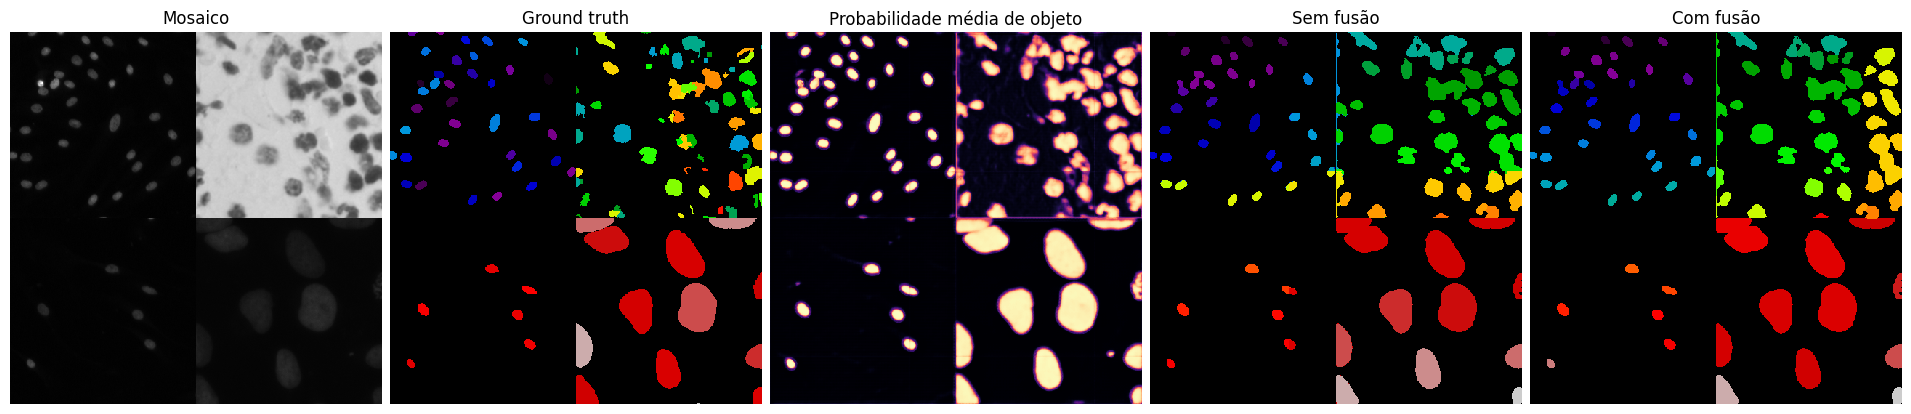

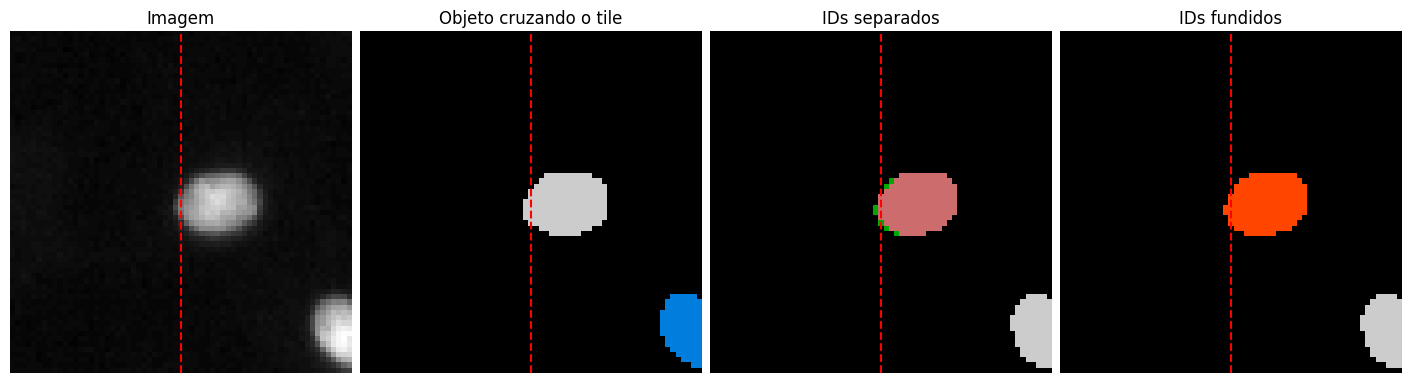

In [ ]:
# Usamos as primeiras quatro imagens de teste, em ordem fixa. O limiar de
# fusão (0,15) foi fixado antes de olhar o resultado deste mosaico.
mosaic_ids = test_final["image_id"].head(4).tolist()
mosaic_image, mosaic_truth = make_mosaic(DATA_ROOT_FINAL, mosaic_ids)
tile_size, stride = 256, 192
tiles, mean_probabilities, coverage = predict_tiles(
    model_final, decoder_final, device_final, mosaic_image, tile_size, stride
)
naive_mosaic = naive_stitch(tiles, mosaic_image.shape)
merged_mosaic = merge_stitch(tiles, mosaic_image.shape, minimum_overlap_iou=0.15)

naive_metrics = calculate_instance_metrics(mosaic_truth, naive_mosaic)
merged_metrics = calculate_instance_metrics(mosaic_truth, merged_mosaic)
part4_table = pd.DataFrame([
    {"método": "IDs locais sem fusão", **naive_metrics},
    {"método": "Fusão por IoU na sobreposição", **merged_metrics},
])
display(part4_table.round(4))
Path("results").mkdir(exist_ok=True)
part4_table.to_csv("results/part4_mosaic.csv", index=False)
print("Tiles:", len(tiles), "| cobertura mínima/máxima:", coverage.min(), coverage.max())
print("IDs das quatro imagens:", mosaic_ids)

fig, axes = plt.subplots(1, 5, figsize=(19, 4), constrained_layout=True)
images = [mosaic_image, mosaic_truth, 1 - mean_probabilities[0],
          naive_mosaic, merged_mosaic]
titles = ["Mosaico", "Ground truth", "Probabilidade média de objeto",
          "Sem fusão", "Com fusão"]
cmaps = ["gray", "nipy_spectral", "magma", "nipy_spectral", "nipy_spectral"]
for axis, image, title, cmap in zip(axes, images, titles, cmaps):
    axis.imshow(image, cmap=cmap, interpolation="nearest")
    axis.set_title(title)
    axis.axis("off")
plt.show()

# Procuramos um objeto verdadeiro que cruza uma borda interna de tile (x=192).
crossing = (mosaic_truth[:, 191] == mosaic_truth[:, 192]) & (mosaic_truth[:, 191] > 0)
if crossing.any():
    center_y = int(np.flatnonzero(crossing)[0])
    rows = slice(max(0, center_y - 32), min(512, center_y + 33))
    columns = slice(160, 225)
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), constrained_layout=True)
    for axis, image, title in zip(
        axes,
        [mosaic_image, mosaic_truth, naive_mosaic, merged_mosaic],
        ["Imagem", "Objeto cruzando o tile", "IDs separados", "IDs fundidos"],
    ):
        axis.imshow(image[rows, columns], cmap="gray" if title == "Imagem" else "nipy_spectral")
        axis.axvline(192 - columns.start, color="red", linestyle="--")
        axis.set_title(title)
        axis.axis("off")
    plt.show()
else:
    print("Nenhum objeto das quatro imagens cruzou x=192; confira outras bordas na figura.")

## Parte 5 — Galeria de falhas, campo receptivo e correção

Usamos as **cinco piores imagens de validação**, selecionadas pelo mAP de
instâncias. O conjunto de teste não escolhe a correção. A galeria mostra a
imagem, a verdade, a predição e a probabilidade de fronteira. O diagnóstico
de cada caso combina contagem prevista/real e tamanho dos objetos; ele é uma
hipótese observável, não uma explicação causal automática.

A colega propôs dilatar o gargalo da U-Net. Na primeira versão, ela retirou
um `MaxPool` mas manteve três `ConvTranspose`, o que causa incompatibilidade
de tamanhos. A versão abaixo mantém o mesmo *output stride* 8 e troca apenas
as duas convoluções do gargalo por convoluções com dilatação 2. Assim o campo
receptivo teórico do encoder passa de 68 para 100 pixels, sem mudar a grade.

Campo receptivo: original 68 px; Atrous 100 px
Output stride dos dois modelos: 8
Núcleos medidos: 20245
Diâmetros (mediana, P90, máximo): [ 23.  45. 139.]
Fração com diâmetro > RF original: 0.017288219313410718


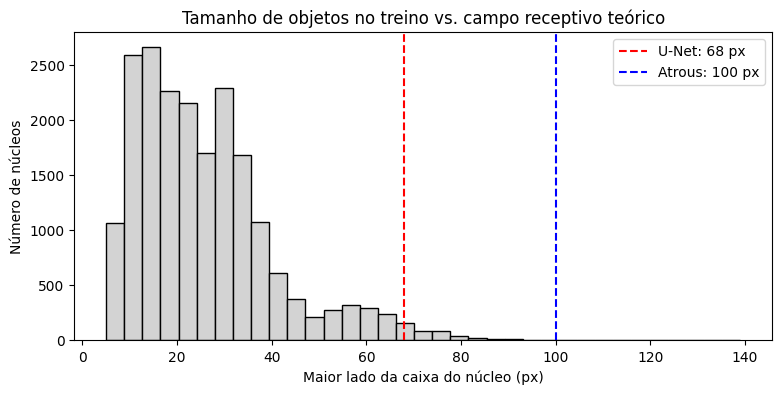

In [ ]:
rf_original, stride_original = encoder_receptive_field(bottleneck_dilation=1)
rf_atrous, stride_atrous = encoder_receptive_field(bottleneck_dilation=2)
assert (rf_original, rf_atrous) == (68, 100)
assert stride_original == stride_atrous == 8

# Medimos a distribuição no treino, sem consultar o conjunto de teste.
diameters = object_diameters(DATA_ROOT_FINAL, train_final["image_id"].tolist())
print("Campo receptivo: original", rf_original, "px; Atrous", rf_atrous, "px")
print("Output stride dos dois modelos:", stride_original)
print("Núcleos medidos:", len(diameters))
print("Diâmetros (mediana, P90, máximo):", np.percentile(diameters, [50, 90, 100]))
print("Fração com diâmetro > RF original:", np.mean(diameters > rf_original))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(diameters, bins=35, color="lightgray", edgecolor="black")
ax.axvline(rf_original, color="red", linestyle="--", label=f"U-Net: {rf_original} px")
ax.axvline(rf_atrous, color="blue", linestyle="--", label=f"Atrous: {rf_atrous} px")
ax.set(xlabel="Maior lado da caixa do núcleo (px)", ylabel="Número de núcleos",
       title="Tamanho de objetos no treino vs. campo receptivo teórico")
ax.legend()
plt.show()

,image_id,map,true_count,predicted_count,count_error
20,33a5b0ff232b425796ee6a9dd5b516ff9aad54ca723b4e...,0.0514,23,13,10
35,57bd029b19c1b382bef9db3ac14f13ea85e36a6053b92e...,0.0760,9,32,23
25,40946065f7e4b6038599fbfd419f2a67e7635b6f89db3e...,0.0828,15,11,4
6,13f2bec0a24c70345372febb14c4352877b1b6c1b01896...,0.0899,17,18,1
82,ddf1bf458312de2895dd9cc5ce7ec9d334ad54c35edc96...,0.0905,30,11,19


33a5b0ff232b... | mAP=0.051 | real=23, previsto=13 | núcleo 8: melhor IoU=0.01, diâmetro=35px (RF=68px) | Subcontagem: possíveis núcleos unidos/perdidos
57bd029b19c1... | mAP=0.076 | real=9, previsto=32 | núcleo 6: melhor IoU=0.16, diâmetro=106px (RF=68px) | Supercontagem: possíveis núcleos fragmentados
40946065f7e4... | mAP=0.083 | real=15, previsto=11 | núcleo 5: melhor IoU=0.00, diâmetro=22px (RF=68px) | Subcontagem: possíveis núcleos unidos/perdidos
13f2bec0a24c... | mAP=0.090 | real=17, previsto=18 | núcleo 10: melhor IoU=0.00, diâmetro=9px (RF=68px) | Supercontagem: possíveis núcleos fragmentados
ddf1bf458312... | mAP=0.090 | real=30, previsto=11 | núcleo 2: melhor IoU=0.00, diâmetro=11px (RF=68px) | Subcontagem: possíveis núcleos unidos/perdidos


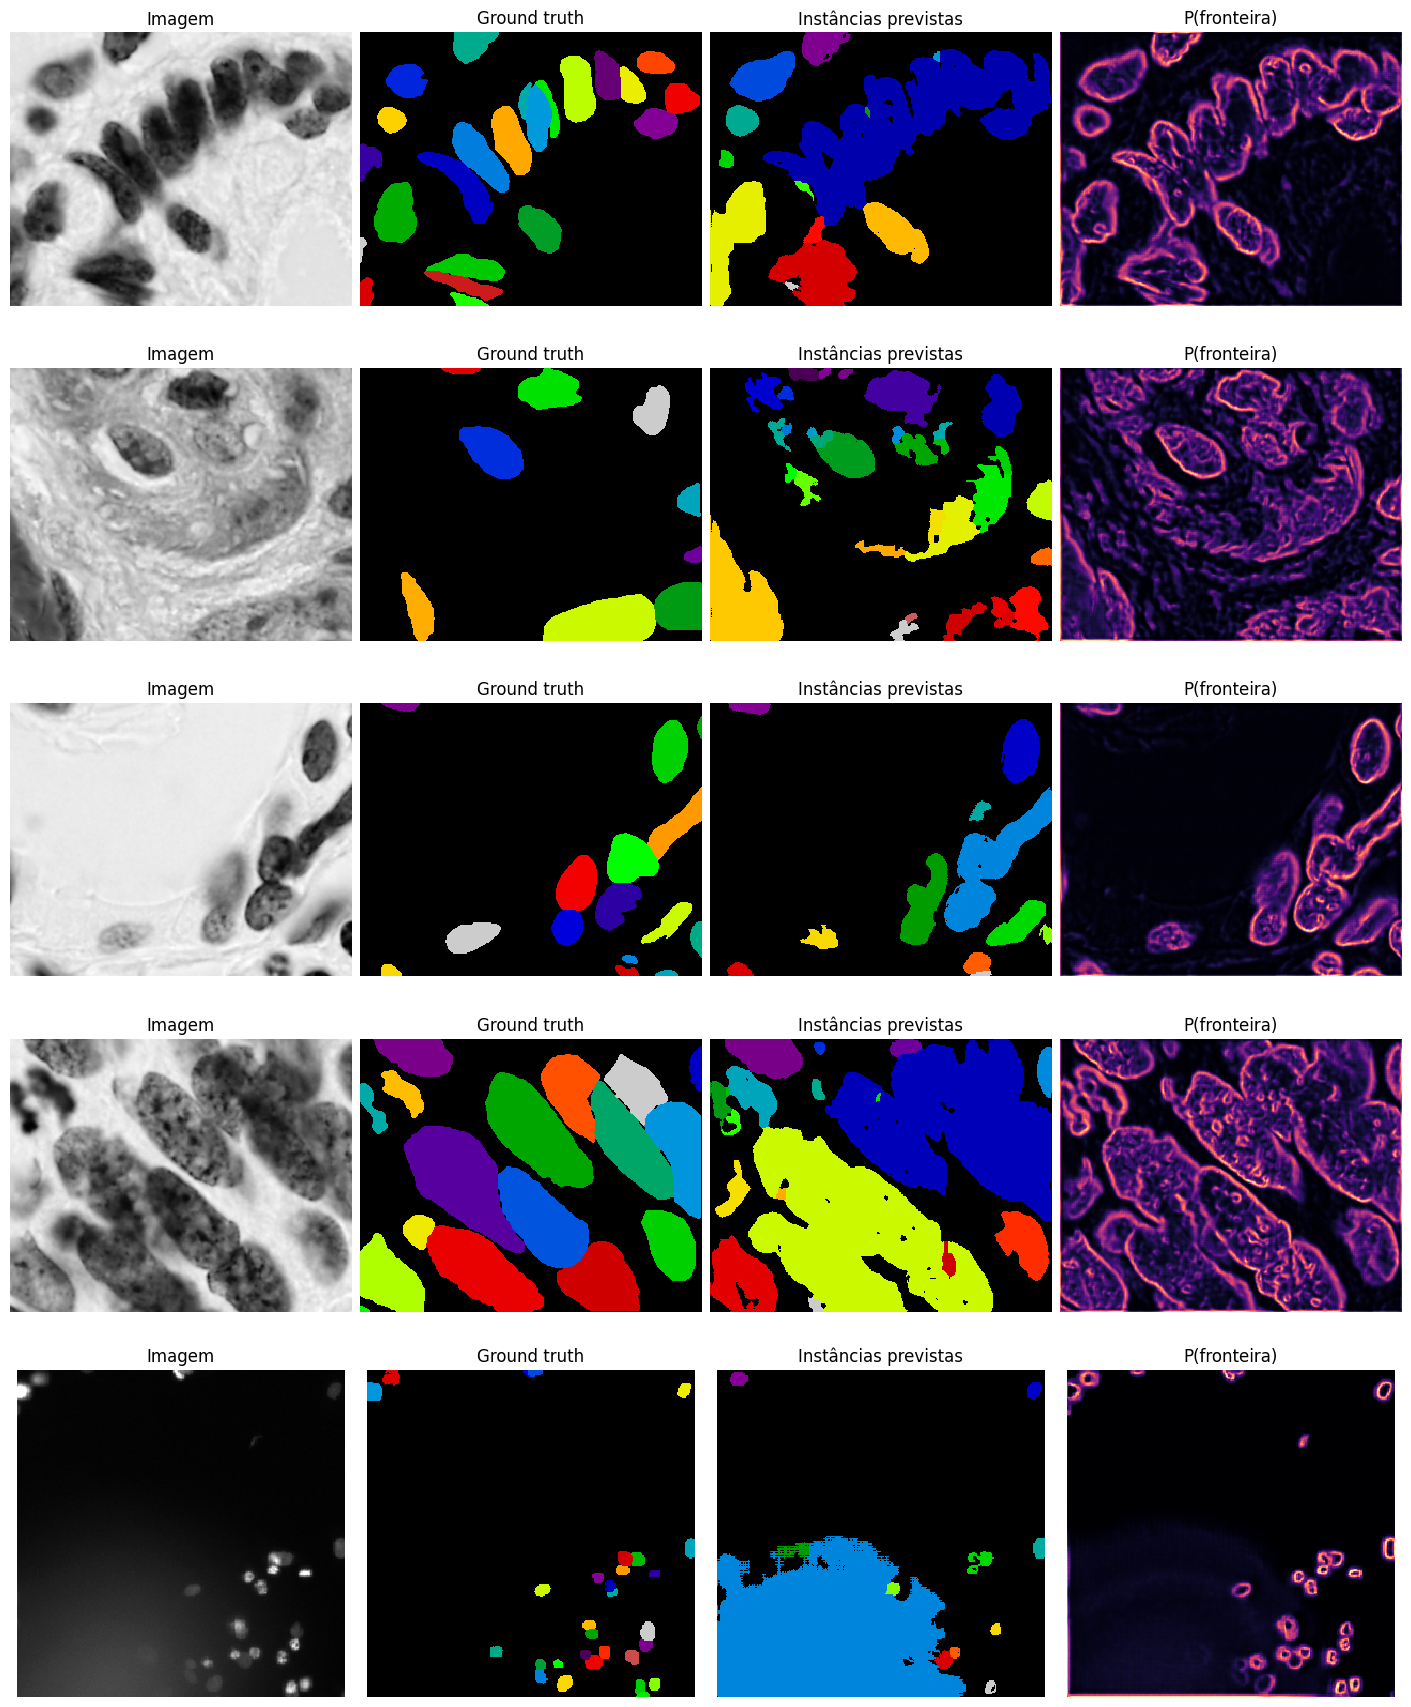

In [ ]:
from scipy.ndimage import find_objects

validation_cases = evaluate_ids(
    DATA_ROOT_FINAL, val_final["image_id"].tolist(),
    model_final, decoder_final, device_final,
)
validation_cases.to_csv("results/part5_validation_cases.csv", index=False)
worst_five = validation_cases.nsmallest(5, "map")
display(worst_five.round(4))

fig, axes = plt.subplots(5, 4, figsize=(14, 17), constrained_layout=True)
for row, case in enumerate(worst_five.itertuples()):
    image, truth = load_sample(DATA_ROOT_FINAL, case.image_id)
    prediction, probabilities = predict_sample(
        model_final, decoder_final, device_final, image
    )
    # Localiza um núcleo verdadeiro mal correspondido e mede a sua caixa.
    iou_pairs = instance_iou_matrix(truth, prediction)
    if iou_pairs.shape[1] > 0:
        best_iou_per_true = iou_pairs.max(axis=1)
    else:
        best_iou_per_true = np.zeros(case.true_count)
    worst_id = int(np.argmin(best_iou_per_true)) + 1
    region = find_objects(truth)[worst_id - 1]
    diameter = max(region[0].stop - region[0].start,
                   region[1].stop - region[1].start)
    if case.predicted_count < case.true_count:
        diagnosis = "Subcontagem: possíveis núcleos unidos/perdidos"
    elif case.predicted_count > case.true_count:
        diagnosis = "Supercontagem: possíveis núcleos fragmentados"
    else:
        diagnosis = "Contagem igual, mas correspondências/localização ruins"
    print(f"{case.image_id[:12]}... | mAP={case.map:.3f} | "
          f"real={case.true_count}, previsto={case.predicted_count} | "
          f"núcleo {worst_id}: melhor IoU={best_iou_per_true[worst_id-1]:.2f}, "
          f"diâmetro={diameter}px (RF={rf_original}px) | {diagnosis}")

    maps = [image, truth, prediction, probabilities[2]]
    titles = ["Imagem", "Ground truth", "Instâncias previstas", "P(fronteira)"]
    cmaps = ["gray", "nipy_spectral", "nipy_spectral", "magma"]
    for axis, data, title, cmap in zip(axes[row], maps, titles, cmaps):
        axis.imshow(data, cmap=cmap, interpolation="nearest")
        axis.set_title(title)
        axis.axis("off")
plt.show()

In [ ]:
class DoubleConvAtrous(nn.Module):
    # Duas convoluções dilatadas, com padding que preserva altura e largura.
    def __init__(self, in_channels, out_channels, dilation=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation,
                      dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=dilation,
                      dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SmallUNetAtrous(SmallUNet):
    def __init__(self):
        super().__init__(in_channels=1, out_channels=3, base_channels=16)
        # Os três MaxPool e os três upsamplings permanecem pareados.
        self.bottleneck = DoubleConvAtrous(64, 128, dilation=2)


test_atrous = SmallUNetAtrous().eval()
with torch.inference_mode():
    assert test_atrous(torch.zeros(1, 1, 256, 256)).shape == (1, 3, 256, 256)
del test_atrous
print("Atrous: saída 3x256x256; output stride permanece 8.")

Atrous: saída 3x256x256; output stride permanece 8.


### Correção experimental: fine-tuning Atrous

Inicializamos com os pesos da Parte 2 porque as formas dos filtros são iguais;
muda apenas a dilatação no gargalo. Treinamos no mesmo split e com a mesma CE
balanceada; a época é escolhida no mAP da **validação**. O decoder permanece
fixo. O teste só é avaliado na célula seguinte. Execute o treino em máquina
com GPU e mude `RUN_ATROUS_TRAINING` para `True`. O valor `False` evita começar
um treino pesado sem querer quando você abrir o notebook.

In [ ]:
from copy import deepcopy

ATROUS_CHECKPOINT = Path("checkpoints/small_unet_atrous.pt")
RUN_ATROUS_TRAINING = False  # Altere para True somente se quiser repetir o treino.
ATROUS_EPOCHS = 6

if RUN_ATROUS_TRAINING:
    if "boundary_train_loader" not in globals() or "train_boundary_one_epoch" not in globals():
        raise RuntimeError("Execute antes as células de dataset e treino da Parte 2.")
    torch.manual_seed(42)
    np.random.seed(42)
    boundary_loader_generator.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    atrous_model = SmallUNetAtrous().to(device_final)
    atrous_model.load_state_dict(model_final.state_dict())
    base_checkpoint = torch.load(CHECKPOINT_FINAL, map_location=device_final,
                                 weights_only=True)
    atrous_weights = torch.tensor(base_checkpoint["class_weights"],
                                  dtype=torch.float32, device=device_final)
    atrous_criterion = nn.CrossEntropyLoss(weight=atrous_weights)
    atrous_optimizer = torch.optim.Adam(atrous_model.parameters(), lr=0.001)
    best_map, best_epoch, best_state = -1.0, None, None
    atrous_history = []

    for epoch in range(1, ATROUS_EPOCHS + 1):
        loss = train_boundary_one_epoch(
            atrous_model, boundary_train_loader, atrous_optimizer,
            atrous_criterion, device_final,
        )
        validation = evaluate_ids(
            DATA_ROOT_FINAL, val_final["image_id"].tolist(),
            atrous_model, decoder_final, device_final,
        )
        validation_map = float(validation["map"].mean())
        atrous_history.append({"epoch": epoch, "loss": loss,
                               "validation_map": validation_map})
        if validation_map > best_map:
            best_map, best_epoch = validation_map, epoch
            best_state = deepcopy(atrous_model.state_dict())
        print(f"Época {epoch}/{ATROUS_EPOCHS}: loss={loss:.4f}; "
              f"mAP validação={validation_map:.4f}")

    assert best_state is not None
    atrous_model.load_state_dict(best_state)
    ATROUS_CHECKPOINT.parent.mkdir(exist_ok=True)
    torch.save({"model_state_dict": best_state,
                "decoder_parameters": decoder_final,
                "class_weights": atrous_weights.tolist(),
                "best_epoch": best_epoch, "best_validation_map": best_map,
                "split_seed": 42, "history": atrous_history,
                "architecture": "SmallUNetAtrous, bottleneck dilation=2"},
               ATROUS_CHECKPOINT)
    pd.DataFrame(atrous_history).to_csv("results/part5_atrous_history.csv", index=False)
    print("Checkpoint Atrous salvo em:", ATROUS_CHECKPOINT.resolve())
else:
    print("Treino Atrous não executado. Ative RUN_ATROUS_TRAINING na GPU.")

Época 1/6: loss=0.2777; mAP validação=0.1566
Época 2/6: loss=0.2607; mAP validação=0.1567
Época 3/6: loss=0.2498; mAP validação=0.2714
Época 4/6: loss=0.2417; mAP validação=0.2403
Época 5/6: loss=0.2439; mAP validação=0.1260
Época 6/6: loss=0.2663; mAP validação=0.2183
Checkpoint Atrous salvo em: C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\checkpoints\small_unet_atrous.pt


In [ ]:
if ATROUS_CHECKPOINT.is_file():
    atrous_saved = torch.load(ATROUS_CHECKPOINT, map_location=device_final,
                              weights_only=True)
    atrous_model = SmallUNetAtrous().to(device_final)
    atrous_model.load_state_dict(atrous_saved["model_state_dict"])
    atrous_model.eval()

    # Avaliamos as mesmas 101 imagens de teste, sem mudar thresholds pelo teste.
    test_ids = test_final["image_id"].tolist()
    before_rows = evaluate_ids(DATA_ROOT_FINAL, test_ids, model_final,
                               decoder_final, device_final)
    after_rows = evaluate_ids(DATA_ROOT_FINAL, test_ids, atrous_model,
                              decoder_final, device_final)
    comparison_atrous = pd.DataFrame([
        {"modelo": "SmallUNet original", "map": before_rows["map"].mean(),
         "count_mae": before_rows["count_error"].mean()},
        {"modelo": "SmallUNet Atrous", "map": after_rows["map"].mean(),
         "count_mae": after_rows["count_error"].mean()},
    ])
    display(comparison_atrous.round(4))
    comparison_atrous.to_csv("results/part5_atrous_comparison.csv", index=False)
    print("Se não melhorou, tamanho do campo receptivo não explica sozinho as falhas.")
else:
    print("Comparação pendente: execute primeiro o treino Atrous em uma GPU.")

,modelo,map,count_mae
0,SmallUNet original,0.4661,9.8911
1,SmallUNet Atrous,0.4307,14.8020


Se não melhorou, tamanho do campo receptivo não explica sozinho as falhas.


## Parte 6 — Teste de estresse por corrupções

Escolhemos a trilha de **corrupções**: ruído gaussiano, blur gaussiano e
redução conjunta de brilho/contraste, com três intensidades fixas. A versão
inicial da colega media IoU binária; aqui medimos o **mAP de instâncias** pedido
no enunciado, usando a U-Net de três classes e o decoder fixo da Parte 2.
As mesmas 101 imagens de teste e as mesmas máscaras verdadeiras são usadas
em todas as condições. O ruído tem seed fixa por imagem. Não treinamos nem
ajustamos thresholds com essas imagens.

In [ ]:
RUN_STRESS_TEST = False  # Altere para True somente se quiser repetir a avaliação.
STRESS_PATH = Path("results/part6_stress_runs.csv")
conditions = [("limpa", 0)] + [
    (kind, severity)
    for kind in ("ruido", "blur", "brilho_contraste")
    for severity in (1, 2, 3)
]

if RUN_STRESS_TEST:
    existing = pd.read_csv(STRESS_PATH) if STRESS_PATH.is_file() else pd.DataFrame()
    records = existing.to_dict("records") if not existing.empty else []
    completed = {(row["image_id"], row["corruption"], int(row["severity"]))
                 for row in records}
    test_ids = test_final["image_id"].tolist()

    for kind, severity in conditions:
        for index, image_id in enumerate(test_ids):
            key = (image_id, kind, severity)
            if key in completed:
                continue
            image, truth = load_sample(DATA_ROOT_FINAL, image_id)
            corrupted = corrupt_image(image, kind, severity,
                                      seed=42 + index + 1000 * severity)
            prediction, _ = predict_sample(
                model_final, decoder_final, device_final, corrupted
            )
            metrics = calculate_instance_metrics(truth, prediction)
            records.append({"image_id": image_id, "corruption": kind,
                            "severity": severity, "map": metrics["map"],
                            "count_error": metrics["count_error"]})
        pd.DataFrame(records).to_csv(STRESS_PATH, index=False)
        print(f"{kind}, intensidade {severity}: {len(records)} avaliações salvas")
else:
    print("Teste de estresse não executado. Ative RUN_STRESS_TEST na GPU.")

limpa, intensidade 0: 101 avaliações salvas
ruido, intensidade 1: 202 avaliações salvas
ruido, intensidade 2: 303 avaliações salvas
ruido, intensidade 3: 404 avaliações salvas
blur, intensidade 1: 505 avaliações salvas
blur, intensidade 2: 606 avaliações salvas
blur, intensidade 3: 707 avaliações salvas
brilho_contraste, intensidade 1: 808 avaliações salvas
brilho_contraste, intensidade 2: 909 avaliações salvas
brilho_contraste, intensidade 3: 1010 avaliações salvas


,corruption,severity,map_mean,map_std,count_mae,n
0,blur,1,0.4551,0.2080,10.2970,101
1,blur,2,0.3808,0.1776,11.1287,101
2,blur,3,0.3109,0.1663,12.4356,101
3,brilho_contraste,1,0.4418,0.2382,9.5446,101
4,brilho_contraste,2,0.3918,0.2940,11.0792,101
5,brilho_contraste,3,0.3360,0.3145,17.7624,101
6,limpa,0,0.4661,0.2135,9.8911,101
7,ruido,1,0.1628,0.1999,26.7525,101
8,ruido,2,0.0105,0.0219,453.5545,101
9,ruido,3,0.0018,0.0066,628.2277,101


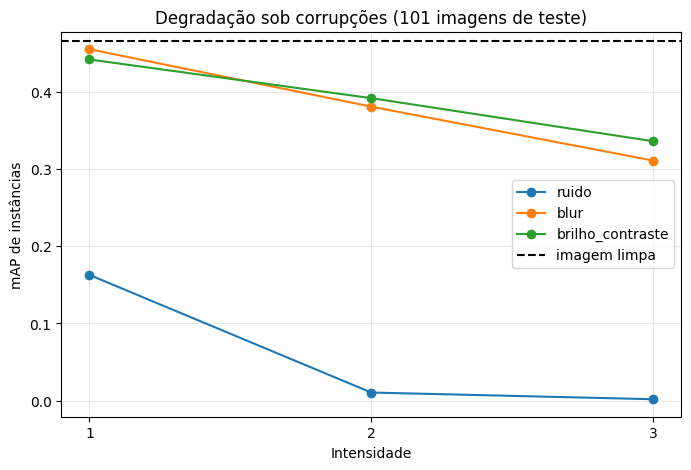

In [ ]:
if STRESS_PATH.is_file():
    stress_rows = pd.read_csv(STRESS_PATH)
    stress_summary = stress_rows.groupby(
        ["corruption", "severity"], as_index=False
    ).agg(map_mean=("map", "mean"), map_std=("map", "std"),
          count_mae=("count_error", "mean"), n=("image_id", "nunique"))
    display(stress_summary.round(4))
    if len(stress_summary) == 10 and (stress_summary["n"] == 101).all():
        clean_map = float(stress_summary.loc[
            stress_summary["corruption"] == "limpa", "map_mean"
        ].iloc[0])
        fig, ax = plt.subplots(figsize=(8, 5))
        for kind in ("ruido", "blur", "brilho_contraste"):
            rows = stress_summary[stress_summary["corruption"] == kind]
            ax.plot(rows["severity"], rows["map_mean"], marker="o", label=kind)
        ax.axhline(clean_map, color="black", linestyle="--", label="imagem limpa")
        ax.set(xlabel="Intensidade", ylabel="mAP de instâncias",
               title="Degradação sob corrupções (101 imagens de teste)")
        ax.set_xticks([1, 2, 3])
        ax.grid(alpha=0.3)
        ax.legend()
        plt.show()
    else:
        print("Resultado parcial: faltam condições ou imagens. Reexecute a célula anterior.")
else:
    print("Resultados pendentes: execute o teste de estresse.")